In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [2]:
# =========================
# Phase 6: Cluster Quality Evaluation
# =========================
# Metrics: NMI, ARI, Purity, Coverage
# Ground truth targets: Level1, Level2, Level3, and full path (from pathlist_names)

import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

INPUT = "phase4_pca_clusters.json"   # from Phase 4
OUT_DIR = "phase6_eval"
PREVIEW_ROWS = 5

# ---------------------------
# Load & prep
# ---------------------------
df = pd.read_json(INPUT, lines=True)

# Ensure string GT columns
for col in ["Level1", "Level2", "Level3", "pathlist_names"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# Normalize full 3-level path from pathlist_names (strict target)
df["GT_Path"] = (
    df["pathlist_names"]
      .str.replace(r"\s*>\s*", " > ", regex=True)
      .str.strip()
)

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---------------------------
# Purity (micro)
# ---------------------------
def purity_score(y_true_str: np.ndarray, y_pred: np.ndarray) -> float:
    # sum over clusters of dominant GT label / total
    if y_pred.size == 0:
        return np.nan
    total = y_pred.size
    best_sum = 0
    for cid in np.unique(y_pred):
        mask = (y_pred == cid)
        if not np.any(mask):
            continue
        majority = Counter(y_true_str[mask]).most_common(1)[0][1]
        best_sum += majority
    return best_sum / total

# ---------------------------
# One evaluation run
# ---------------------------
def evaluate_one(df_part: pd.DataFrame, gt_col: str, exclude_noise: bool = True):
    sub = df_part.copy()
    if exclude_noise:
        sub = sub[sub["HDBSCAN_Cluster"] >= 0]
    if sub.empty:
        return None, None

    y_true_cat = sub[gt_col].astype("category")
    y_true = y_true_cat.cat.codes.values
    y_pred = sub["HDBSCAN_Cluster"].values

    nmi = normalized_mutual_info_score(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    purity = purity_score(y_true_cat.astype(str).values, y_pred)

    metrics = {
        "n_points_eval": len(sub),
        "coverage": len(sub) / len(df_part) if len(df_part) else 0.0,
        "n_clusters": sub["HDBSCAN_Cluster"].nunique(),
        "nmi": float(nmi),
        "ari": float(ari),
        "purity": float(purity),
    }

    # cluster -> majority GT table
    rows = []
    for cid, g in sub.groupby("HDBSCAN_Cluster"):
        vc = g[gt_col].value_counts()
        maj_label = vc.index[0]
        maj_count = int(vc.iloc[0])
        size = len(g)
        rows.append({
            "cluster_id": int(cid),
            "size": size,
            "major_gt_label": maj_label,
            "major_count": maj_count,
            "cluster_purity": maj_count / size
        })
    maj_tbl = pd.DataFrame(rows).sort_values(["size", "cluster_id"], ascending=[False, True])
    return metrics, maj_tbl

# ---------------------------
# Run across splits & targets
# ---------------------------
targets = ["Level1", "Level2", "Level3", "GT_Path"]

splits = [("ALL", df)]
if "dataset" in df.columns:
    for name in sorted(df["dataset"].unique()):
        splits.append((name.upper(), df[df["dataset"] == name].copy()))

all_results = []

for split_name, part in splits:
    print(f"\n=== Split: {split_name} ===")
    total = len(part)
    noise = int((part["HDBSCAN_Cluster"] == -1).sum()) if "HDBSCAN_Cluster" in part.columns else 0
    print(f"Total points: {total} | Noise: {noise}")

    for tgt in targets:
        metrics, maj_tbl = evaluate_one(part, tgt, exclude_noise=True)
        if metrics is None:
            print(f"  {tgt}: no evaluable points.")
            continue

        all_results.append({
            "split": split_name,
            "gt": tgt,
            **metrics
        })

        print(f"  -> {tgt:8s} | coverage={metrics['coverage']:.2%} | "
              f"clusters={metrics['n_clusters']:3d} | "
              f"NMI={metrics['nmi']:.4f} | ARI={metrics['ari']:.4f} | Purity={metrics['purity']:.4f}")

        # Save per-target majority table for this split
        out_csv = f"{OUT_DIR}/majority_{split_name}_{tgt}.csv".replace(" ", "_")
        maj_tbl.to_csv(out_csv, index=False)
        print(maj_tbl.head(PREVIEW_ROWS).to_string(index=False))

# Summary CSV
pd.DataFrame(all_results).to_csv(f"{OUT_DIR}/phase6_summary.csv", index=False)

print("\n✅ Phase 6 complete.")
print(f"Saved summary: {OUT_DIR}/phase6_summary.csv")
print(f"Saved majority tables: {OUT_DIR}/majority_*_*.csv")



=== Split: ALL ===
Total points: 6000 | Noise: 2635
  -> Level1   | coverage=56.08% | clusters= 38 | NMI=0.0000 | ARI=0.0000 | Purity=1.0000
 cluster_id  size          major_gt_label  major_count  cluster_purity
         36  1258 Computers & Electronics         1258             1.0
         26   185 Computers & Electronics          185             1.0
         29   176 Computers & Electronics          176             1.0
         25   149 Computers & Electronics          149             1.0
         17   148 Computers & Electronics          148             1.0
  -> Level2   | coverage=56.08% | clusters= 38 | NMI=0.6463 | ARI=0.3862 | Purity=0.9608
 cluster_id  size     major_gt_label  major_count  cluster_purity
         36  1258          Computers         1242        0.987281
         26   185          Computers          185        1.000000
         29   176          Computers          176        1.000000
         25   149          Computers          132        0.885906
         17  

C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Loaded graph: 188 nodes, 235 edges


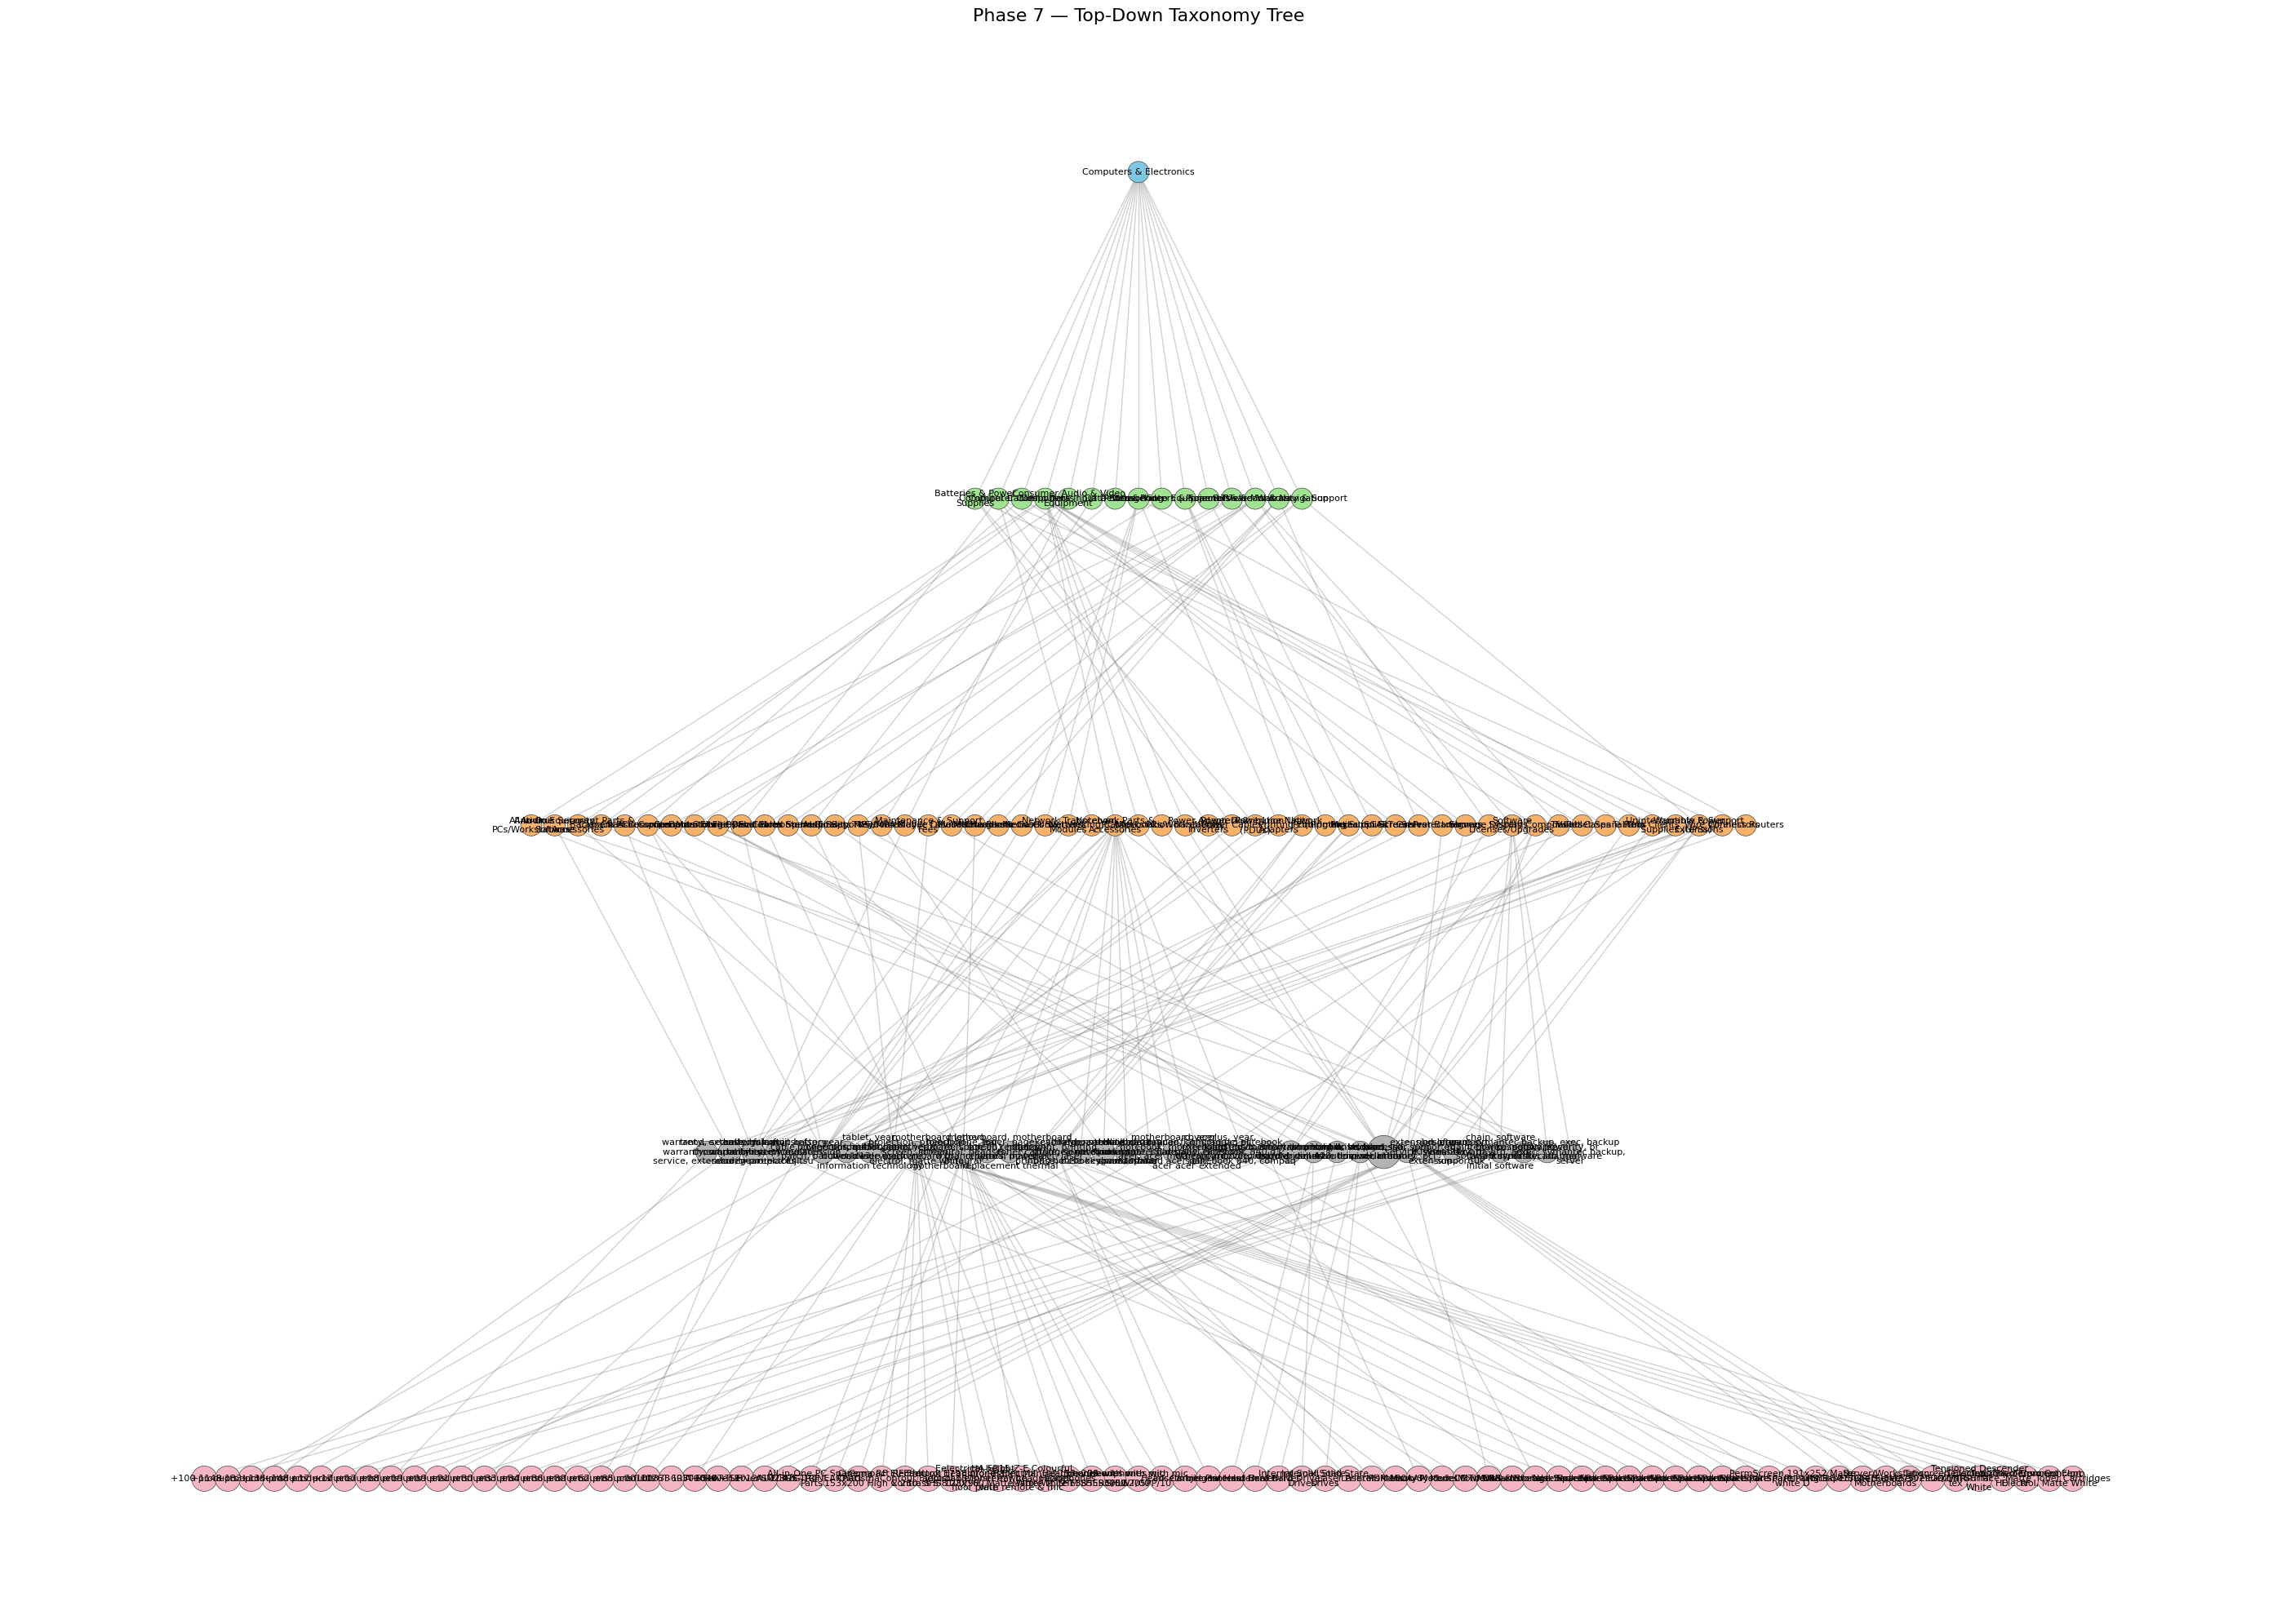

✅ Phase 7 complete
Saved: phase7_topdown_tree.png
Saved: phase7_topdown_tree.pdf


In [3]:
#PHASE7
# =========================
# Phase 7: Top-Down Taxonomy Visualization (No Graphviz)
# =========================
# WHAT: Read the Phase-5 graph (node-link JSON) and draw a top-down layered tree:
#       Level1 → Level2 → Level3 → Cluster → (optional) Level4 product leaves.
# WHY: Clear, presentation-ready figure that mirrors the taxonomy spine and your
#      discovered topic clusters, with optional product context.

import json
from pathlib import Path
from textwrap import wrap
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
from networkx.readwrite import json_graph

# ---------------------------
# Inputs / Outputs
# ---------------------------
GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # from Phase 5
PNG_OUT = "phase7_topdown_tree.png"
PDF_OUT = "phase7_topdown_tree.pdf"
HTML_OUT = "phase7_topdown_tree.html"         # optional, only if you enable Plotly below

# ---------------------------
# Controls
# ---------------------------
INCLUDE_LEVEL4 = True      # show Level4 products (leaves)
COLLAPSE_LABELS = True     # wrap long labels to multiple lines
LABEL_WRAP_CHARS = 24
MAX_LABEL_CHARS = 80       # hard truncate extremely long labels (after wrapping)
FIGSIZE = (28, 20)         # bigger canvas if labels feel small
NODE_BASE_SIZE = 350       # base node size (matplotlib points^2)
LEAF_NODE_SIZE = 500       # a bit bigger so leaves stand out
CLUSTER_NODE_SIZE_SCALE = 0.4  # multiply by cluster 'size' to scale node
EDGE_ALPHA = 0.35

# Optional: render just a single Level1 branch (keeps picture small).
# Set to None to render ALL, or set to a specific Level1 label, e.g.:
# FOCUS_L1 = "Computers & Electronics"
FOCUS_L1 = None

# ---------------------------
# 1) Load graph
# ---------------------------
# WHAT: Phase 5 exported a node-link JSON, which retains node attributes like 'type', 'label', 'size'.
# WHY: Easy to reconstruct the exact graph without version-specific pickle formats.

with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True)

# Quick sanity
print("Loaded graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 2) Optionally filter to one Level1 branch
# ---------------------------
if FOCUS_L1 is not None:
    # Find the Level1 node key with this label
    l1_keys = [n for n, d in G.nodes(data=True) if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if len(l1_keys) == 0:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found in graph labels.")
    root = l1_keys[0]

    # Grab all descendants of that L1
    keep = set([root])
    keep.update(nx.descendants(G, root))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 3) Optionally hide Level4 leaves entirely
# ---------------------------
if not INCLUDE_LEVEL4:
    drop_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(drop_nodes)
    print("Removed Level4 leaves:", len(drop_nodes))

# ---------------------------
# 4) Compute a top-down layered layout
# ---------------------------
# WHAT: Assign y by hierarchy level (fixed), x by order within each level.
# WHY: Makes a clean “root-at-top” picture without Graphviz.

level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
# Fallback for any unexpected types:
def node_level(d):
    return level_order.get(d.get("type", "cluster"), 4)

# Group nodes by level
levels = defaultdict(list)
for n, d in G.nodes(data=True):
    levels[node_level(d)].append(n)

# Sort nodes within a level deterministically (by label)
for lvl in levels:
    levels[lvl].sort(key=lambda n: G.nodes[n].get("label", ""))

# Assign coordinates: spread nodes horizontally, stack levels vertically
pos = {}
for lvl in sorted(levels.keys()):
    nodes = levels[lvl]
    # center x around 0 for each level
    xs = list(range(len(nodes)))
    xs = [x - (len(nodes)-1)/2.0 for x in xs]
    for x, n in zip(xs, nodes):
        pos[n] = (x, -lvl)  # negative y → top-down

# ---------------------------
# 5) Node styling helpers
# ---------------------------
def wrap_label(text, width=24, hard_cap=80):
    if text is None:
        return ""
    text = str(text)
    if hard_cap and len(text) > hard_cap:
        text = text[: hard_cap - 1] + "…"
    if COLLAPSE_LABELS:
        return "\n".join(wrap(text, width=width))
    return text

def node_color(d):
    t = d.get("type")
    if t == "level1": return "#7ec8e3"   # sky-ish
    if t == "level2": return "#a0e493"   # light green
    if t == "level3": return "#f6b26b"   # orange
    if t == "cluster": return "#b3b3b3"  # gray
    return "#f4b6c2"                     # leaf (pink)

def node_size(n, d):
    # Make cluster nodes scale with the cluster size metadata from Phase 5
    if d.get("type") == "cluster":
        size = d.get("size", 1)
        return max(NODE_BASE_SIZE, NODE_BASE_SIZE + size * CLUSTER_NODE_SIZE_SCALE)
    if d.get("type") == "leaf":
        return LEAF_NODE_SIZE
    return NODE_BASE_SIZE

# Precompute visuals
node_sizes = [node_size(n, d) for n, d in G.nodes(data=True)]
node_colors = [node_color(d) for _, d in G.nodes(data=True)]
labels = {}
for n, d in G.nodes(data=True):
    lbl = d.get("label", "")
    # For cluster nodes, show only the TF-IDF label (we already see the cluster number in the key)
    if d.get("type") == "cluster":
        # Their 'label' was like "cid: comma-terms" in Phase 5; we only keep the part after the colon
        lbl = lbl.split(":", 1)[-1].strip() if ":" in lbl else lbl
    labels[n] = wrap_label(lbl, width=LABEL_WRAP_CHARS, hard_cap=MAX_LABEL_CHARS)

# ---------------------------
# 6) Draw (matplotlib)
# ---------------------------
plt.figure(figsize=FIGSIZE)

# Edges first (thin & light)
nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    alpha=EDGE_ALPHA,
    arrows=False
)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    linewidths=0.5,
    edgecolors="#444444"
)

# Labels
nx.draw_networkx_labels(
    G, pos, labels=labels,
    font_size=8,
    verticalalignment="center",
    horizontalalignment="center"
)

plt.title("Phase 7 — Top-Down Taxonomy Tree", fontsize=16, pad=12)
plt.axis("off")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=200)
plt.savefig(PDF_OUT)
plt.show()

print("✅ Phase 7 complete")
print("Saved:", PNG_OUT)
print("Saved:", PDF_OUT)

# ---------------------------
# 7) (Optional) Interactive HTML with Plotly
# ---------------------------
# NOTE: Requires `pip install plotly`. Comment this block out if you don't need it.
ENABLE_PLOTLY = False
if ENABLE_PLOTLY:
    import plotly.graph_objects as go

    xs = [pos[n][0] for n in G.nodes()]
    ys = [pos[n][1] for n in G.nodes()]
    texts = [labels[n] for n in G.nodes()]
    sizes = [max(6, s**0.5 / 2) for s in node_sizes]  # convert matplotlib size → marker size

    # Edges as separate scatter segments
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=1, color='rgba(120,120,120,0.35)'),
        hoverinfo='none',
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode='markers+text',
        text=texts,
        textposition='middle center',
        marker=dict(
            size=sizes,
            color=node_colors,
            line=dict(width=1, color='rgba(60,60,60,0.8)')
        ),
        hovertext=[G.nodes[n].get("type", "") for n in G.nodes()],
        hoverinfo='text',
        showlegend=False
    ))

    fig.update_layout(
        title="Phase 7 — Top-Down Taxonomy Tree (Interactive)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=20, r=20, t=60, b=20),
        width=1400, height=1000
    )
    fig.write_html(HTML_OUT, include_plotlyjs="cdn")
    print("Saved interactive:", HTML_OUT)


In [2]:
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Load Phase 4 output (same file you used in Phase 6)
df_all = pd.read_json("phase4_pca_clusters.json", lines=True)

# Build a single GT label: the full L1 > L2 > L3 path
def build_path(s):
    return " > ".join([s.get("Level1",""), s.get("Level2",""), s.get("Level3","")]).strip(" >")

df_all["GT_Path"] = df_all.apply(build_path, axis=1)
print(df_all["GT_Path"].head())

# Keep only non-noise points (HDBSCAN_Cluster >= 0)
mask = df_all["HDBSCAN_Cluster"] >= 0
df = df_all[mask].copy()

# y_true: full ground-truth path; y_pred: cluster ids
y_true = df["GT_Path"]
y_pred = df["HDBSCAN_Cluster"]

# One single overall score across ALL (non-noise) points
overall_nmi = normalized_mutual_info_score(y_true, y_pred)
overall_ari = adjusted_rand_score(y_true, y_pred)

coverage = len(df) / len(df_all) if len(df_all) else 0.0

print(f"Overall NMI (vs GT_Path): {overall_nmi:.4f}")
print(f"Overall ARI (vs GT_Path): {overall_ari:.4f}")


0    Computers & Electronics > Computers > PCs/Work...
1    Computers & Electronics > Computers > Notebook...
2    Computers & Electronics > Computer Cables > Fi...
3    Computers & Electronics > Computers > Handheld...
4    Computers & Electronics > Computers > PCs/Work...
Name: GT_Path, dtype: object
Overall NMI (vs GT_Path): 0.7468
Overall ARI (vs GT_Path): 0.5326


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Loaded graph: 188 nodes, 235 edges


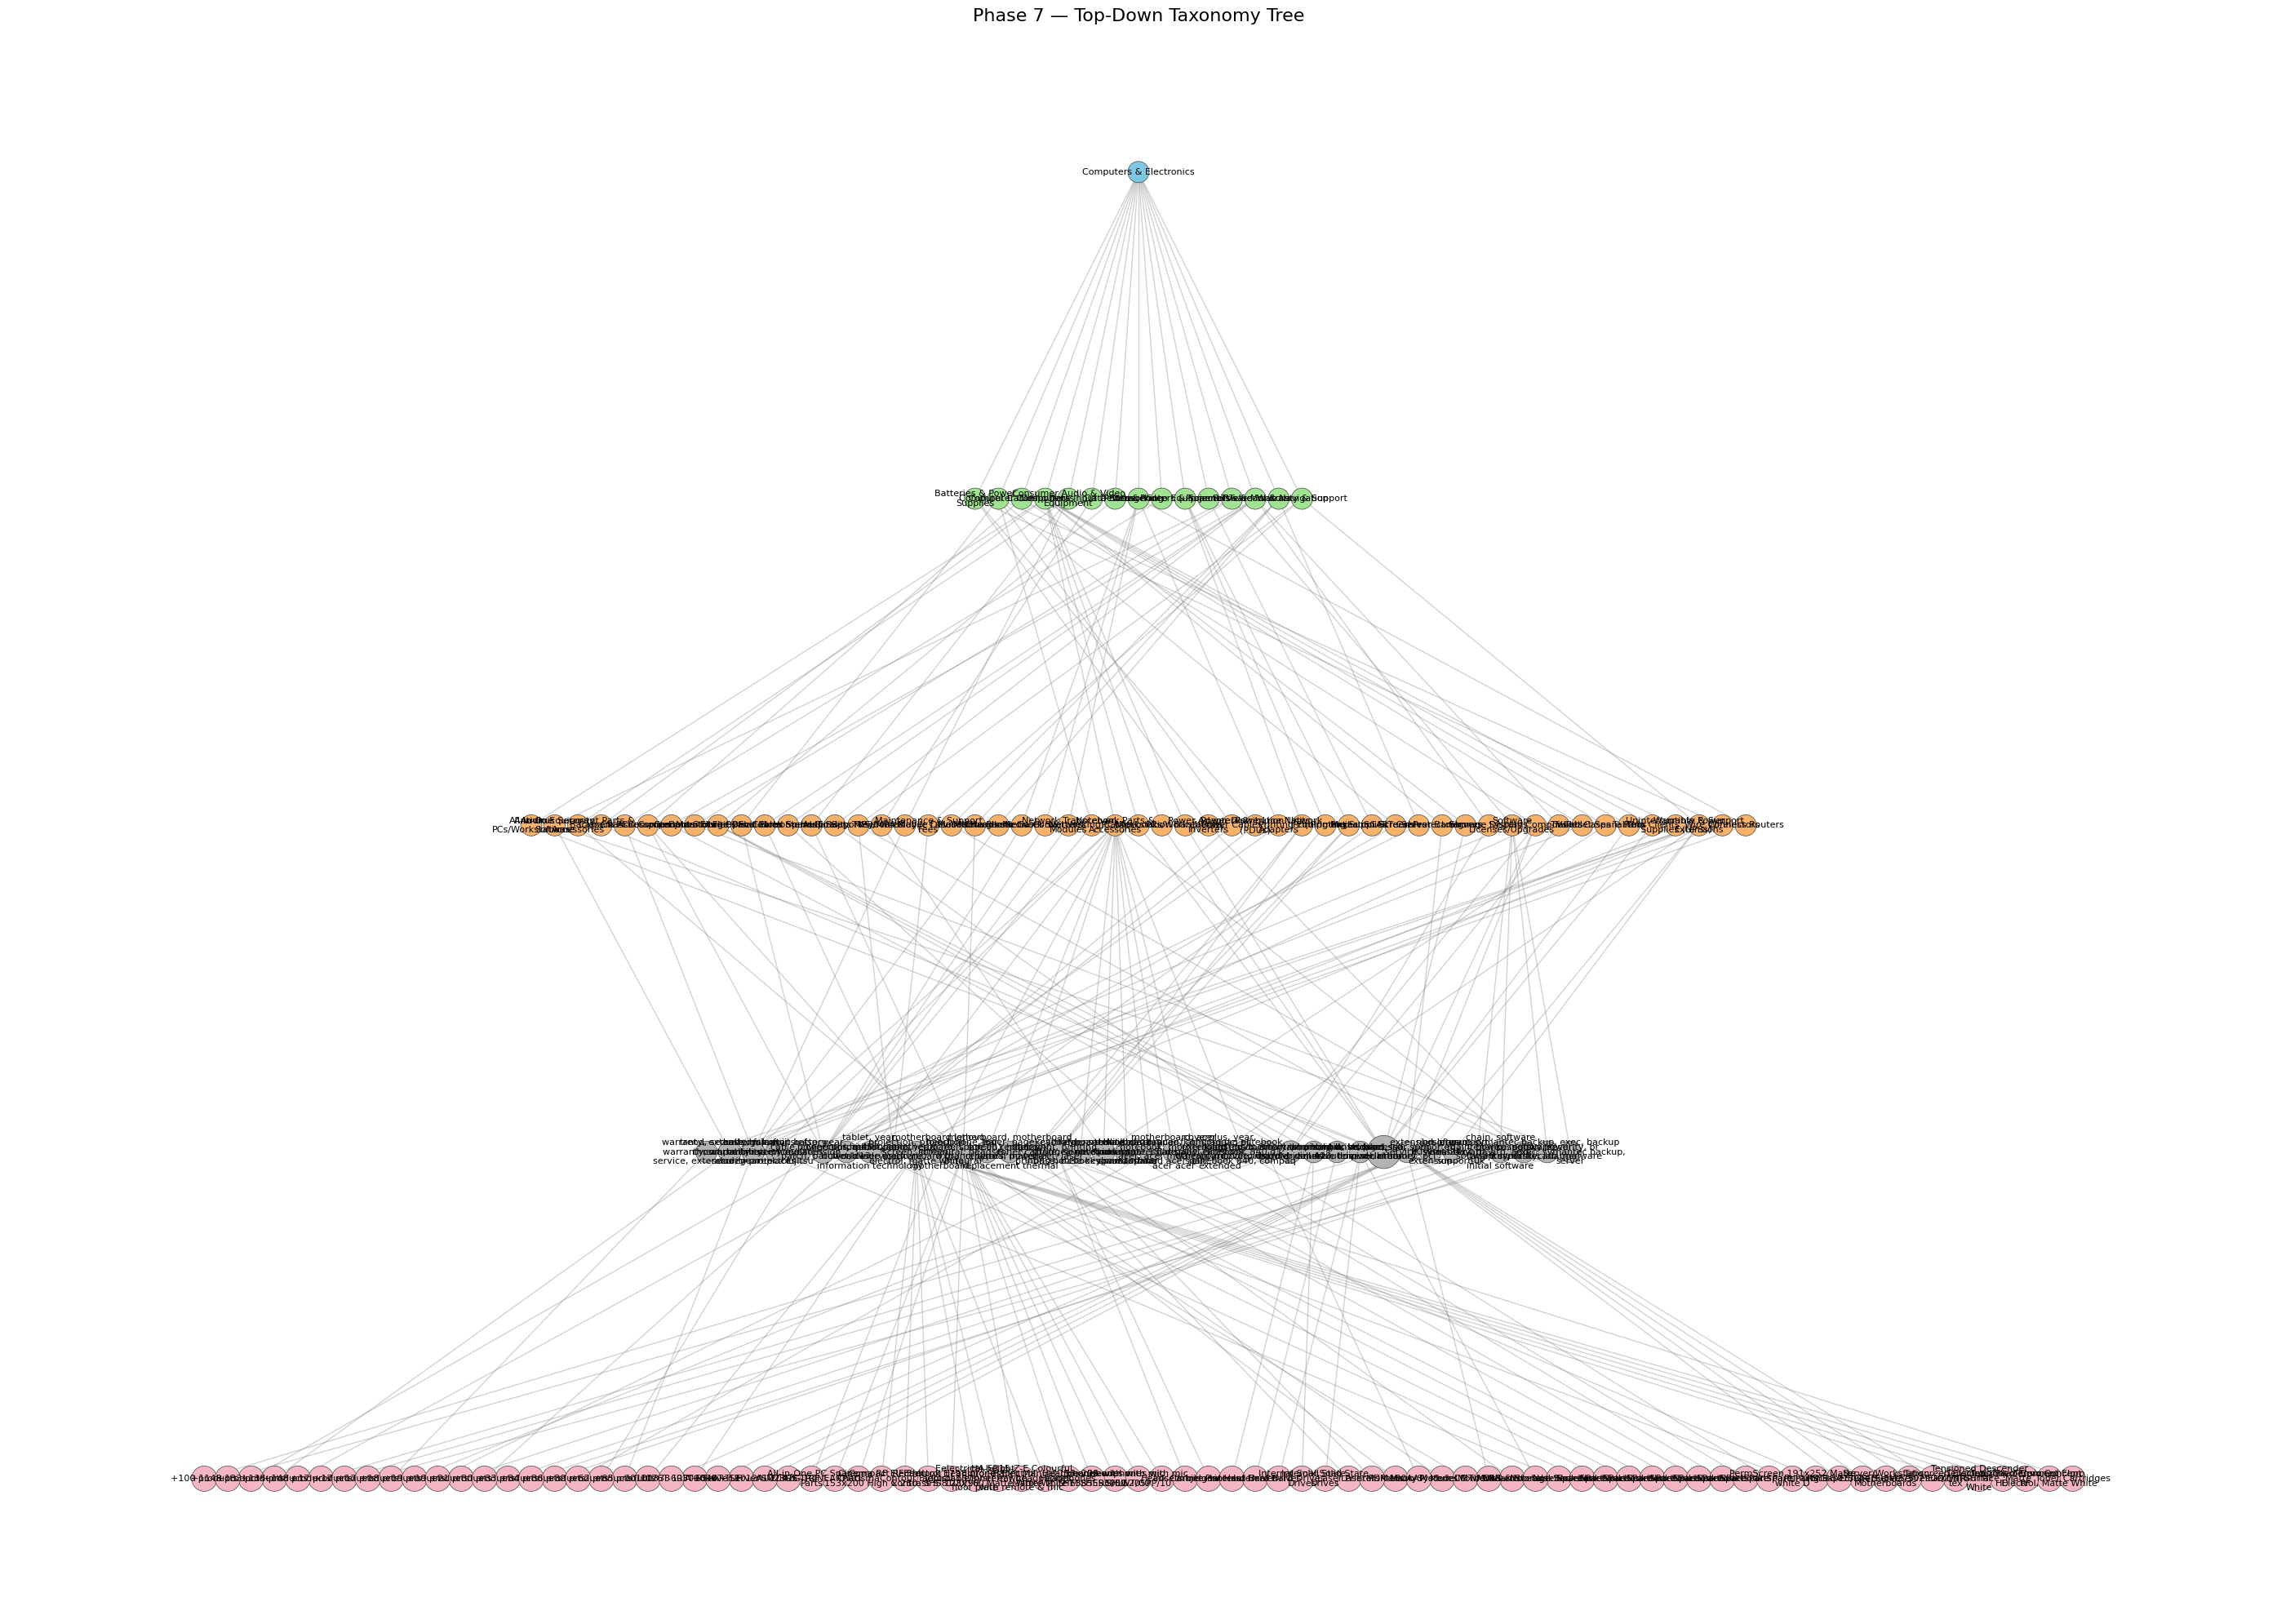

✅ Phase 7 complete
Saved: phase7_topdown_tree.png
Saved: phase7_topdown_tree.pdf
Saved interactive: phase7_topdown_tree.html


In [3]:
# =========================
# Phase 7: Top-Down Taxonomy Visualization (Static + Interactive)
# =========================
# - Loads Phase 5's node-link JSON graph
# - Draws a layered tree (L1 -> L2 -> L3 -> Cluster -> Level4 leaves)
# - Saves static PNG/PDF with matplotlib
# - Saves interactive HTML with Plotly (hover tooltips: labels, types, cluster stats)

import json
from pathlib import Path
from textwrap import wrap
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
from networkx.readwrite import json_graph

# ---------------------------
# Inputs / Outputs
# ---------------------------
GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # from Phase 5
PNG_OUT = "phase7_topdown_tree.png"
PDF_OUT = "phase7_topdown_tree.pdf"
HTML_OUT = "phase7_topdown_tree.html"         # interactive Plotly

# ---------------------------
# Controls
# ---------------------------
INCLUDE_LEVEL4 = True         # show Level4 product leaves
COLLAPSE_LABELS = True        # wrap long labels to multiple lines
LABEL_WRAP_CHARS = 24
MAX_LABEL_CHARS = 80          # hard truncate extremely long labels (after wrapping)
FIGSIZE = (28, 20)
NODE_BASE_SIZE = 350          # matplotlib node area (points^2)
LEAF_NODE_SIZE = 500
CLUSTER_NODE_SIZE_SCALE = 0.4 # matplotlib node area grows with cluster size
EDGE_ALPHA = 0.35

# Optional: render just a single Level1 branch (keeps picture small).
# Set to None to render ALL, or set to a specific Level1 label, e.g.:
# FOCUS_L1 = "Computers & Electronics"
FOCUS_L1 = None

# ---------------------------
# 1) Load graph
# ---------------------------
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)

print("Loaded graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 2) Optionally focus on one Level1 branch
# ---------------------------
if FOCUS_L1 is not None:
    l1_keys = [n for n, d in G.nodes(data=True)
               if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if not l1_keys:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found in graph labels.")
    root = l1_keys[0]
    keep = set([root])
    keep.update(nx.descendants(G, root))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 3) Optionally hide Level4 leaves entirely
# ---------------------------
if not INCLUDE_LEVEL4:
    drop_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(drop_nodes)
    print("Removed Level4 leaves:", len(drop_nodes))

# ---------------------------
# 4) Compute a top-down layered layout
# ---------------------------
level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(d):  # fallback to "cluster" level if missing
    return level_order.get(d.get("type", "cluster"), 4)

levels = defaultdict(list)
for n, d in G.nodes(data=True):
    levels[node_level(d)].append(n)

# deterministic left->right ordering by label
for lvl in levels:
    levels[lvl].sort(key=lambda n: (G.nodes[n].get("label") or ""))

pos = {}
for lvl in sorted(levels.keys()):
    nodes = levels[lvl]
    xs = list(range(len(nodes)))
    xs = [x - (len(nodes) - 1) / 2.0 for x in xs]  # center around 0
    for x, n in zip(xs, nodes):
        pos[n] = (x, -lvl)  # negative y makes it top-down

# ---------------------------
# 5) Styling helpers
# ---------------------------
def wrap_label(text, width=24, hard_cap=80):
    if text is None:
        return ""
    text = str(text)
    if hard_cap and len(text) > hard_cap:
        text = text[: hard_cap - 1] + "…"
    return "\n".join(wrap(text, width=width)) if COLLAPSE_LABELS else text

def node_color(d):
    t = d.get("type")
    if t == "level1": return "#7ec8e3"   # sky-ish
    if t == "level2": return "#a0e493"   # light green
    if t == "level3": return "#f6b26b"   # orange
    if t == "cluster": return "#b3b3b3"  # gray
    return "#f4b6c2"                     # leaf (pink)

def node_size(n, d):
    if d.get("type") == "cluster":
        size = d.get("size", 1)
        return max(NODE_BASE_SIZE, NODE_BASE_SIZE + size * CLUSTER_NODE_SIZE_SCALE)
    if d.get("type") == "leaf":
        return LEAF_NODE_SIZE
    return NODE_BASE_SIZE

node_sizes = [node_size(n, d) for n, d in G.nodes(data=True)]
node_colors = [node_color(d) for _, d in G.nodes(data=True)]

labels = {}
for n, d in G.nodes(data=True):
    lbl = d.get("label", "") or ""
    if d.get("type") == "cluster":
        # Phase 5 stored "cid: tfidf terms"; show just the TF-IDF names
        lbl = lbl.split(":", 1)[-1].strip() if ":" in lbl else lbl
    labels[n] = wrap_label(lbl, width=LABEL_WRAP_CHARS, hard_cap=MAX_LABEL_CHARS)

# ---------------------------
# 6) Draw static (matplotlib)
# ---------------------------
plt.figure(figsize=FIGSIZE)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    alpha=EDGE_ALPHA,
    arrows=False
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    linewidths=0.5,
    edgecolors="#444444"
)

nx.draw_networkx_labels(
    G, pos, labels=labels,
    font_size=8,
    verticalalignment="center",
    horizontalalignment="center"
)

plt.title("Phase 7 — Top-Down Taxonomy Tree", fontsize=16, pad=12)
plt.axis("off")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=200)
plt.savefig(PDF_OUT)
plt.show()

print("✅ Phase 7 complete")
print("Saved:", PNG_OUT)
print("Saved:", PDF_OUT)

# ---------------------------
# 7) Interactive HTML with Plotly — rich hover tooltips
# ---------------------------
# pip install plotly
ENABLE_PLOTLY = True
if ENABLE_PLOTLY:
    import plotly.graph_objects as go

    # Convert matplotlib "area" size to a reasonable Plotly marker size
    def to_plotly_size(area):
        return max(6, (area ** 0.5) / 2.0)

    # Node arrays
    node_ids, xs, ys, node_colors_plotly, sizes_plotly, hover_lines = [], [], [], [], [], []

    def color_for(d):
        return node_color(d)

    for n, d in G.nodes(data=True):
        node_ids.append(n)
        xs.append(pos[n][0])
        ys.append(pos[n][1])
        sizes_plotly.append(to_plotly_size(node_size(n, d)))
        node_colors_plotly.append(color_for(d))

        ntype = d.get("type", "")
        raw_label = d.get("label", "") or ""
        tfidf_label = raw_label.split(":", 1)[-1].strip() if ":" in raw_label else raw_label
        cluster_id = d.get("cluster_id", None)
        cluster_size = d.get("size", None)
        top_terms = d.get("top_terms", []) or []
        terms_txt = ", ".join(top_terms[:8]) if top_terms else ""

        if ntype == "cluster":
            title = tfidf_label if tfidf_label else f"Cluster {cluster_id}"
            line2 = f"Cluster ID: {cluster_id} | Size: {cluster_size}"
            line3 = f"Top terms: {terms_txt}" if terms_txt else ""
            hover_lines.append(f"<b>{title}</b><br>Type: {ntype}<br>{line2}<br>{line3}")
        else:
            title = raw_label if raw_label else n
            hover_lines.append(f"<b>{title}</b><br>Type: {ntype}")

    # Edge segments
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    fig = go.Figure()

    # Edges
    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=1, color='rgba(120,120,120,0.35)'),
        hoverinfo='none',
        showlegend=False
    ))

    # Nodes
    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode='markers',
        marker=dict(
            size=sizes_plotly,
            color=node_colors_plotly,
            line=dict(width=1, color='rgba(60,60,60,0.8)')
        ),
        text=hover_lines,
        hovertemplate="%{text}<extra></extra>",
        showlegend=False
    ))

    fig.update_layout(
        title="Phase 7 — Top-Down Taxonomy Tree (Interactive)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=20, r=20, t=60, b=20),
        width=1400, height=1000
    )

    fig.write_html(HTML_OUT, include_plotlyjs="cdn")
    print("Saved interactive:", HTML_OUT)

# ---------------------------
# 8) (Optional) PyVis explorer
# ---------------------------
# pip install pyvis
ENABLE_PYVIS = False
if ENABLE_PYVIS:
    from pyvis.network import Network
    nt = Network(height="900px", width="100%", bgcolor="#ffffff", directed=True)
    nt.barnes_hut()

    for n, d in G.nodes(data=True):
        title = d.get("label", "") or n
        size = 8
        if d.get("type") == "cluster":
            size = 8 + 0.04 * d.get("size", 1)
        nt.add_node(n, label=d.get("label",""), title=title, size=size)

    for u, v in G.edges():
        nt.add_edge(u, v)

    nt.show("phase7_pyvis.html")
    print("Saved PyVis:", "phase7_pyvis.html")


In [4]:
# --- Plotly interactive view of Phase-5 taxonomy ---
# pip install plotly

import json
from collections import defaultdict
import networkx as nx
from networkx.readwrite import json_graph
import plotly.graph_objects as go

GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # from Phase 5

# 1) Load graph
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)

# 2) Simple top-down layout (by node "type")
level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(d): return level_order.get(d.get("type", "cluster"), 4)

levels = defaultdict(list)
for n, d in G.nodes(data=True):
    levels[node_level(d)].append(n)

for lvl in levels:
    levels[lvl].sort(key=lambda n: (G.nodes[n].get("label") or ""))

pos = {}
for lvl in sorted(levels.keys()):
    nodes = levels[lvl]
    xs = list(range(len(nodes)))
    xs = [x - (len(nodes)-1)/2.0 for x in xs]
    for x, n in zip(xs, nodes):
        pos[n] = (x, -lvl)

# 3) Styling helpers
def node_color(d):
    t = d.get("type")
    return {
        "level1": "#7ec8e3",
        "level2": "#a0e493",
        "level3": "#f6b26b",
        "cluster": "#b3b3b3",
        "leaf": "#f4b6c2",
    }.get(t, "#cccccc")

def node_size(d):
    base = 18
    if d.get("type") == "cluster":
        # scale a bit with cluster size
        return min(40, base + 0.03 * d.get("size", 1))
    if d.get("type") == "leaf":
        return 16
    return 18

def hover_text(n, d):
    t = d.get("type", "")
    raw_label = d.get("label", "") or n
    tfidf_label = raw_label.split(":", 1)[-1].strip() if (t == "cluster" and ":" in raw_label) else raw_label
    top_terms = d.get("top_terms", [])
    terms_txt = ", ".join(top_terms[:8]) if top_terms else ""
    if t == "cluster":
        lines = [
            f"<b>{tfidf_label or raw_label}</b>",
            f"Type: {t}",
            f"Cluster ID: {d.get('cluster_id', '')} | Size: {d.get('size', '')}",
        ]
        if terms_txt: lines.append(f"Top terms: {terms_txt}")
        return "<br>".join(lines)
    else:
        return f"<b>{raw_label}</b><br>Type: {t}"

# 4) Build Plotly traces
# Edges
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=1, color="rgba(120,120,120,0.35)"),
    hoverinfo="none",
    showlegend=False,
)

# Nodes (one trace for all types is fine; hover shows details)
xs, ys, sizes, colors, hovers = [], [], [], [], []
for n, d in G.nodes(data=True):
    xs.append(pos[n][0])
    ys.append(pos[n][1])
    sizes.append(node_size(d))
    colors.append(node_color(d))
    hovers.append(hover_text(n, d))

node_trace = go.Scatter(
    x=xs, y=ys,
    mode="markers",
    marker=dict(size=sizes, color=colors, line=dict(width=1, color="rgba(60,60,60,0.8)")),
    text=hovers,
    hovertemplate="%{text}<extra></extra>",
    showlegend=False,
)

# 5) Render inline
fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="Phase 7 — Top-Down Taxonomy Tree (Interactive)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20),
    width=1200, height=800,
)

fig.show()  # <-- displays the interactive graph inline


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning:


The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.



In [ ]:
#------------------------------------------------------------------------------------------------

In [1]:
# =========================
# Phase 6: Evaluation & QA
# =========================
# WHAT: Compare HDBSCAN clusters to ground-truth taxonomy.
#       Metrics: NMI, ARI, Purity at L1/L2/L3 and full path (GT_Path).
#       Handles noise (-1), prints coverage, and saves CSVs.
# OUTPUTS:
#   phase6_eval/phase6_summary.csv
#   phase6_eval/majority_<split>_<level>.csv

import os
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# ---------------------------
# Settings
# ---------------------------
INPUT = "phase4_pca_clusters.json"   # from Phase 4
OUT_DIR = Path("phase6_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_COL = "HDBSCAN_Cluster"
L1, L2, L3 = "Level1", "Level2", "Level3"
SPLIT_COL = "Split"  # optional; if not present we evaluate ALL only

# ---------------------------
# Load + sanity
# ---------------------------
df = pd.read_json(INPUT, lines=True)

# Ensure expected columns exist
for c in [CLUSTER_COL, L1, L2, L3]:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# Make a full-path ground-truth label
if "GT_Path" not in df.columns:
    df["GT_Path"] = (
        df[L1].fillna("").astype(str).str.strip() + " > " +
        df[L2].fillna("").astype(str).str.strip() + " > " +
        df[L3].fillna("").astype(str).str.strip()
    )

# Optionally create a single ALL split if none provided
if SPLIT_COL not in df.columns:
    df["Split"] = "ALL"

# Normalize types
df[CLUSTER_COL] = df[CLUSTER_COL].astype(int)

# ---------------------------
# Helpers
# ---------------------------
def cluster_majority_table(dfi: pd.DataFrame, gt_col: str) -> pd.DataFrame:
    """
    Per-cluster majority ground-truth label table, purity per cluster.
    Noise (-1) is excluded from the table.
    """
    sub = dfi[dfi[CLUSTER_COL] >= 0].copy()
    rows = []
    for cid, g in sub.groupby(CLUSTER_COL):
        counts = g[gt_col].value_counts(dropna=False)
        major_label = counts.index[0]
        major_cnt = counts.iloc[0]
        size = len(g)
        purity = major_cnt / size if size else 0.0
        rows.append({
            "cluster_id": cid,
            "size": size,
            "major_gt_label": major_label,
            "major_count": major_cnt,
            "cluster_purity": purity
        })
    out = pd.DataFrame(rows).sort_values(["size", "cluster_id"], ascending=[False, True])
    return out

def overall_purity_from_majority(tbl: pd.DataFrame) -> float:
    """Overall purity = sum of cluster majorities / sum of cluster sizes."""
    if tbl.empty:
        return 0.0
    return tbl["major_count"].sum() / tbl["size"].sum()

def coverage(dfi: pd.DataFrame) -> float:
    """Coverage = proportion of non-noise points."""
    n_total = len(dfi)
    if n_total == 0:
        return 0.0
    n_used = (dfi[CLUSTER_COL] >= 0).sum()
    return n_used / n_total

def nmi_ari(dfi: pd.DataFrame, gt_col: str) -> tuple[float, float]:
    """
    Compute NMI/ARI between clusters and ground-truth labels.
    IMPORTANT: Only non-noise rows (cluster >= 0) are used.
    """
    sub = dfi[dfi[CLUSTER_COL] >= 0]
    if sub.empty:
        return 0.0, 0.0
    y_pred = sub[CLUSTER_COL].astype(int).to_numpy()
    y_true = sub[gt_col].astype(str).to_numpy()
    return (
        normalized_mutual_info_score(y_true, y_pred),
        adjusted_rand_score(y_true, y_pred),
    )

# ---------------------------
# Evaluate per-split
# ---------------------------
levels = [("Level1", L1), ("Level2", L2), ("Level3", L3), ("GT_Path", "GT_Path")]

summary_rows = []

for split_name, dsplit in df.groupby("Split"):
    n_total = len(dsplit)
    n_noise = (dsplit[CLUSTER_COL] < 0).sum()
    cov = coverage(dsplit)*100

    print(f"\n=== Split: {split_name} ===")
    print(f"Total points: {n_total} | Noise: {n_noise}")

    for nice_name, col in levels:
        tbl = cluster_majority_table(dsplit, col)
        pur = overall_purity_from_majority(tbl)
        nmi, ari = nmi_ari(dsplit, col)
        cov2 = coverage(dsplit)  # same as cov; included for clarity

        print(f"  -> {nice_name:<7} | coverage={cov2*100:.2f}% | clusters={tbl.shape[0]:3d} | "
              f"NMI={nmi:.4f} | ARI={ari:.4f} | Purity={pur:.4f}")

        # Save majority table
        out_csv = OUT_DIR / f"majority_{split_name}_{nice_name}.csv"
        tbl.to_csv(out_csv, index=False)

        # Append summary row
        summary_rows.append({
            "split": split_name,
            "level": nice_name,
            "coverage": cov2,
            "n_clusters": int(tbl.shape[0]),
            "NMI": nmi,
            "ARI": ari,
            "Purity": pur,
            "total_points": int(n_total),
            "noise_points": int(n_noise),
        })

# ---------------------------
# Save summary
# ---------------------------
summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "phase6_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\n✅ Phase 6 complete.")
print("Saved summary:", summary_path)
print("Saved majority tables: phase6_eval/majority_*_*.csv")



=== Split: ALL ===
Total points: 6000 | Noise: 2635
  -> Level1  | coverage=56.08% | clusters= 38 | NMI=0.0000 | ARI=0.0000 | Purity=1.0000
  -> Level2  | coverage=56.08% | clusters= 38 | NMI=0.6463 | ARI=0.3862 | Purity=0.9608
  -> Level3  | coverage=56.08% | clusters= 38 | NMI=0.7468 | ARI=0.5326 | Purity=0.8357
  -> GT_Path | coverage=56.08% | clusters= 38 | NMI=0.7468 | ARI=0.5326 | Purity=0.8357

✅ Phase 6 complete.
Saved summary: phase6_eval\phase6_summary.csv
Saved majority tables: phase6_eval/majority_*_*.csv


In [4]:
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

df = pd.read_json("phase4_pca_clusters.json", lines=True)

# Build full path label if it's not there already
if "GT_Path" not in df.columns:
    df["GT_Path"] = (
        df["Level1"].fillna("").astype(str).str.strip() + " > " +
        df["Level2"].fillna("").astype(str).str.strip() + " > " +
        df["Level3"].fillna("").astype(str).str.strip()
    )

# Keep only non-noise points
sub = df[df["HDBSCAN_Cluster"] >= 0].copy()


y_pred = sub["HDBSCAN_Cluster"].astype(int).to_numpy()
y_true = sub["GT_Path"].astype(str).to_numpy()

overall_nmi = normalized_mutual_info_score(y_true, y_pred)
print("Overall NMI (GT_Path, non-noise):", round(overall_nmi, 4))



Overall NMI (GT_Path, non-noise): 0.7468


In [5]:
# =========================
# Phase 6: Clustering Evaluation (Overall + Per Level)
# =========================

import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# ---------------------------
# Inputs / Outputs
# ---------------------------
PHASE4_IN = "phase4_pca_clusters.json"          # Phase 4 output (has HDBSCAN_Cluster)
PHASE5_SUMMARY_IN = "phase5_cluster_summary.csv" # Optional: to attach TF-IDF names/top_terms in tables
OUT_DIR = Path("phase6_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_OUT = OUT_DIR / "phase6_summary.csv"     # compact per-level summary (ALL + per split)
MAJ_PREFIX = OUT_DIR / "majority"                # we’ll write multiple CSVs with this prefix

# ---------------------------
# Load data
# ---------------------------
df_all = pd.read_json(PHASE4_IN, lines=True)

# Build a single ground-truth path if not present
if "GT_Path" not in df_all.columns:
    df_all["GT_Path"] = (
        df_all["Level1"].fillna("").astype(str).str.strip() + " > " +
        df_all["Level2"].fillna("").astype(str).str.strip() + " > " +
        df_all["Level3"].fillna("").astype(str).str.strip()
    )

# If you have a canonical path string like 'pathlist_names', prefer it:
if "pathlist_names" in df_all.columns:
    # Use non-empty pathlist_names; otherwise keep existing GT_Path
    mask = df_all["pathlist_names"].notna() & (df_all["pathlist_names"].astype(str).str.strip() != "")
    df_all.loc[mask, "GT_Path"] = df_all.loc[mask, "pathlist_names"].astype(str)

# Non-noise mask
mask_nn = df_all["HDBSCAN_Cluster"] >= 0
df = df_all[mask_nn].copy()

coverage = float(len(df)) / float(len(df_all)) if len(df_all) else 0.0

# ---------------------------
# Helper functions
# ---------------------------
def purity(y_true, y_pred):
    # Weighted cluster purity (majority label share in each cluster, weighted by cluster size)
    if len(y_true) == 0:
        return 0.0
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    total = len(y_true)
    score = 0
    for cid in np.unique(y_pred):
        idx = (y_pred == cid)
        majorsize = Counter(y_true[idx]).most_common(1)[0][1]
        score += majorsize
    return score / total

def compute_metrics(y_true, y_pred):
    return {
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "Purity": purity(y_true, y_pred)
    }

def majority_table(df_slice, gt_col):
    rows = []
    for cid, sub in df_slice.groupby("HDBSCAN_Cluster"):
        counts = sub[gt_col].value_counts()
        major_label = counts.index[0]
        major_count = counts.iloc[0]
        rows.append({
            "cluster_id": int(cid),
            "size": int(len(sub)),
            "major_gt_label": major_label,
            "major_count": int(major_count),
            "cluster_purity": round(major_count/len(sub), 6)
        })
    tab = pd.DataFrame(rows).sort_values(["size"], ascending=False)
    return tab

# Try to load Phase-5 cluster names/top_terms (optional)
phase5_labels = None
if Path(PHASE5_SUMMARY_IN).exists():
    phase5_labels = pd.read_csv(PHASE5_SUMMARY_IN)
    # Expected columns: HDBSCAN_Cluster, label, top_terms
    # Normalize for join
    if "HDBSCAN_Cluster" not in phase5_labels.columns and "cluster_id" in phase5_labels.columns:
        phase5_labels = phase5_labels.rename(columns={"cluster_id": "HDBSCAN_Cluster"})
    phase5_labels["HDBSCAN_Cluster"] = phase5_labels["HDBSCAN_Cluster"].astype(int)

# ---------------------------
# 1) One overall score (non-noise) vs most specific label (GT_Path)
# ---------------------------
y_true_all = df["GT_Path"].astype(str).to_numpy()
y_pred_all = df["HDBSCAN_Cluster"].astype(int).to_numpy()

overall = compute_metrics(y_true_all, y_pred_all)

print(f"Total points: {len(df_all)} | Non-noise: {len(df)} | Coverage: {coverage*100:.2f}%")
print(f"Overall NMI (vs GT_Path): {overall['NMI']:.4f}")
print(f"Overall ARI (vs GT_Path): {overall['ARI']:.4f}")
print(f"Overall Purity: {overall['Purity']:.4f}")

# ---------------------------
# 2) Per-level metrics (ALL and per split if present)
# ---------------------------
levels = [c for c in ["Level1", "Level2", "Level3", "GT_Path"] if c in df_all.columns]
splits = ["ALL"]
if "Split" in df_all.columns:
    splits += sorted(df_all["Split"].dropna().unique().tolist())

summary_rows = []

def eval_block(sub_df, level_name, split_name):
    y_t = sub_df[level_name].astype(str).to_numpy()
    y_p = sub_df["HDBSCAN_Cluster"].astype(int).to_numpy()
    m = compute_metrics(y_t, y_p)
    summary_rows.append({
        "split": split_name,
        "level": level_name,
        "coverage": len(sub_df)/len(df_all) if len(df_all) else 0.0,
        "clusters_used": len(np.unique(y_p)),
        "NMI": m["NMI"],
        "ARI": m["ARI"],
        "Purity": m["Purity"],
        "size": len(sub_df)
    })

    # Majority table for this (split, level)
    maj = majority_table(sub_df, level_name)
    if phase5_labels is not None:
        maj = maj.merge(
            phase5_labels[["HDBSCAN_Cluster", "label", "top_terms"]],
            left_on="cluster_id", right_on="HDBSCAN_Cluster", how="left"
        ).drop(columns=["HDBSCAN_Cluster"])
    out_csv = f"{MAJ_PREFIX}_{split_name}_{level_name}.csv"
    maj.to_csv(out_csv, index=False)

# Evaluate ALL
for lvl in levels:
    eval_block(df, lvl, "ALL")

# Evaluate per split if present
if "Split" in df_all.columns:
    for s in sorted(df_all["Split"].dropna().unique()):
        sub = df_all[(df_all["Split"] == s) & (df_all["HDBSCAN_Cluster"] >= 0)].copy()
        for lvl in levels:
            eval_block(sub, lvl, s)

# Save summary
pd.DataFrame(summary_rows).to_csv(SUMMARY_OUT, index=False)

print("\n✅ Phase 6 complete.")
print("Saved summary:", SUMMARY_OUT)
print("Saved majority tables to:", str(OUT_DIR))


Total points: 6000 | Non-noise: 3365 | Coverage: 56.08%
Overall NMI (vs GT_Path): 0.7630
Overall ARI (vs GT_Path): 0.5472
Overall Purity: 0.8279

✅ Phase 6 complete.
Saved summary: phase6_eval\phase6_summary.csv
Saved majority tables to: phase6_eval


In [6]:
# =========================
# Phase 6: Clustering Evaluation (Overall + Per Level)
# =========================

import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# ---------------------------
# Inputs / Outputs
# ---------------------------
PHASE4_IN = "phase4_pca_clusters.json"          # Phase 4 output (has HDBSCAN_Cluster)
PHASE5_SUMMARY_IN = "phase5_cluster_summary.csv" # Optional: to attach TF-IDF names/top_terms in tables
OUT_DIR = Path("phase6_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_OUT = OUT_DIR / "phase6_summary.csv"     # compact per-level summary (ALL + per split)
MAJ_PREFIX = OUT_DIR / "majority"                # we’ll write multiple CSVs with this prefix

# ---------------------------
# Load data
# ---------------------------
df_all = pd.read_json(PHASE4_IN, lines=True)

# Build a single ground-truth path if not present
if "GT_Path" not in df_all.columns:
    df_all["GT_Path"] = (
        df_all["Level1"].fillna("").astype(str).str.strip() + " > " +
        df_all["Level2"].fillna("").astype(str).str.strip() + " > " +
        df_all["Level3"].fillna("").astype(str).str.strip()
    )

# If you have a canonical path string like 'pathlist_names', prefer it:
if "pathlist_names" in df_all.columns:
    # Use non-empty pathlist_names; otherwise keep existing GT_Path
    mask = df_all["pathlist_names"].notna() & (df_all["pathlist_names"].astype(str).str.strip() != "")
    df_all.loc[mask, "GT_Path"] = df_all.loc[mask, "pathlist_names"].astype(str)

# Non-noise mask
mask_nn = df_all["HDBSCAN_Cluster"] >= 0
df = df_all[mask_nn].copy()

coverage = float(len(df)) / float(len(df_all)) if len(df_all) else 0.0

# ---------------------------
# Helper functions
# ---------------------------
def purity(y_true, y_pred):
    # Weighted cluster purity (majority label share in each cluster, weighted by cluster size)
    if len(y_true) == 0:
        return 0.0
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    total = len(y_true)
    score = 0
    for cid in np.unique(y_pred):
        idx = (y_pred == cid)
        majorsize = Counter(y_true[idx]).most_common(1)[0][1]
        score += majorsize
    return score / total

def compute_metrics(y_true, y_pred):
    return {
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "Purity": purity(y_true, y_pred)
    }

def majority_table(df_slice, gt_col):
    rows = []
    for cid, sub in df_slice.groupby("HDBSCAN_Cluster"):
        counts = sub[gt_col].value_counts()
        major_label = counts.index[0]
        major_count = counts.iloc[0]
        rows.append({
            "cluster_id": int(cid),
            "size": int(len(sub)),
            "major_gt_label": major_label,
            "major_count": int(major_count),
            "cluster_purity": round(major_count/len(sub), 6)
        })
    tab = pd.DataFrame(rows).sort_values(["size"], ascending=False)
    return tab

# Try to load Phase-5 cluster names/top_terms (optional)
phase5_labels = None
if Path(PHASE5_SUMMARY_IN).exists():
    phase5_labels = pd.read_csv(PHASE5_SUMMARY_IN)
    # Expected columns: HDBSCAN_Cluster, label, top_terms
    # Normalize for join
    if "HDBSCAN_Cluster" not in phase5_labels.columns and "cluster_id" in phase5_labels.columns:
        phase5_labels = phase5_labels.rename(columns={"cluster_id": "HDBSCAN_Cluster"})
    phase5_labels["HDBSCAN_Cluster"] = phase5_labels["HDBSCAN_Cluster"].astype(int)

# ---------------------------
# 1) One overall score (non-noise) vs most specific label (GT_Path)
# ---------------------------
y_true_all = df["GT_Path"].astype(str).to_numpy()
y_pred_all = df["HDBSCAN_Cluster"].astype(int).to_numpy()

overall = compute_metrics(y_true_all, y_pred_all)

print(f"Total points: {len(df_all)} | Non-noise: {len(df)} | Coverage: {coverage*100:.2f}%")
print(f"Overall NMI (vs GT_Path): {overall['NMI']:.4f}")
print(f"Overall ARI (vs GT_Path): {overall['ARI']:.4f}")
print(f"Overall Purity: {overall['Purity']:.4f}")


Total points: 6000 | Non-noise: 3365 | Coverage: 56.08%
Overall NMI (vs GT_Path): 0.7630
Overall ARI (vs GT_Path): 0.5472
Overall Purity: 0.8279


In [7]:
# 2) Per-level metrics (ALL and per split if present)
# ---------------------------
levels = [c for c in ["Level1", "Level2", "Level3", "GT_Path"] if c in df_all.columns]
splits = ["ALL"]
if "Split" in df_all.columns:
    splits += sorted(df_all["Split"].dropna().unique().tolist())

summary_rows = []

def eval_block(sub_df, level_name, split_name):
    y_t = sub_df[level_name].astype(str).to_numpy()
    y_p = sub_df["HDBSCAN_Cluster"].astype(int).to_numpy()
    m = compute_metrics(y_t, y_p)
    summary_rows.append({
        "split": split_name,
        "level": level_name,
        "coverage": len(sub_df)/len(df_all) if len(df_all) else 0.0,
        "clusters_used": len(np.unique(y_p)),
        "NMI": m["NMI"],
        "ARI": m["ARI"],
        "Purity": m["Purity"],
        "size": len(sub_df)
    })

    # Majority table for this (split, level)
    maj = majority_table(sub_df, level_name)
    if phase5_labels is not None:
        maj = maj.merge(
            phase5_labels[["HDBSCAN_Cluster", "label", "top_terms"]],
            left_on="cluster_id", right_on="HDBSCAN_Cluster", how="left"
        ).drop(columns=["HDBSCAN_Cluster"])
    out_csv = f"{MAJ_PREFIX}_{split_name}_{level_name}.csv"
    maj.to_csv(out_csv, index=False)

# Evaluate ALL
for lvl in levels:
    eval_block(df, lvl, "ALL")

# Evaluate per split if present
if "Split" in df_all.columns:
    for s in sorted(df_all["Split"].dropna().unique()):
        sub = df_all[(df_all["Split"] == s) & (df_all["HDBSCAN_Cluster"] >= 0)].copy()
        for lvl in levels:
            eval_block(sub, lvl, s)

# Save summary
pd.DataFrame(summary_rows).to_csv(SUMMARY_OUT, index=False)

print("\n✅ Phase 6 complete.")
print("Saved summary:", SUMMARY_OUT)
print("Saved majority tables to:", str(OUT_DIR))


✅ Phase 6 complete.
Saved summary: phase6_eval\phase6_summary.csv
Saved majority tables to: phase6_eval


In [9]:
# Make the existing Phase-5 top-down figure interactive (same layout)
# Requirements: you already have G (networkx graph), pos (dict of positions), labels (dict of label text)
# pip install plotly

import plotly.graph_objects as go

# --- colors & sizes by node type ---
COLOR = {
    "level1": "#7ec8e3",   # blue
    "level2": "#a0e493",   # green
    "level3": "#f6b26b",   # orange
    "cluster": "#b3b3b3",  # gray
    "leaf": "#f4b6c2",     # pink
}
def node_size(d):
    base = 18
    if d.get("type") == "cluster":
        return min(44, base + 0.05*int(d.get("size", 1)))  # scale by cluster size
    if d.get("type") == "leaf":
        return 14
    return 18

def display_label(d):
    t = d.get("type")
    raw = d.get("label", "")
    # show only TF-IDF part for clusters ("cid: terms" -> "terms")
    return raw.split(":", 1)[-1].strip() if (t == "cluster" and ":" in raw) else raw

def hover_text(n, d):
    t = d.get("type", "")
    lbl = display_label(d) or d.get("label") or n
    if t == "cluster":
        terms = d.get("top_terms") or []
        return "<br>".join([
            f"<b>{lbl}</b>",
            f"Type: {t}",
            f"Cluster ID: {d.get('cluster_id','')}",
            f"Size: {d.get('size','')}",
            f"Top terms: {', '.join(map(str, terms[:8]))}" if terms else ""
        ])
    return f"<b>{lbl}</b><br>Type: {t}"

# --- Edges as one polyline trace ---
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=1, color="rgba(120,120,120,0.35)"),
    hoverinfo="none",
    showlegend=False
)

# --- Nodes: one trace per type so you can toggle in legend ---
node_traces = []
for t in ["level1","level2","level3","cluster","leaf"]:
    xs, ys, sizes, texts, show_text = [], [], [], [], []
    for n, d in G.nodes(data=True):
        if d.get("type") != t: 
            continue
        x, y = pos[n]
        xs.append(x); ys.append(y)
        sizes.append(node_size(d))
        texts.append(hover_text(n, d))
        # show text for everything except leaves (keeps it readable)
        show_text.append(display_label(d) if t != "leaf" else "")

    if xs:
        node_traces.append(
            go.Scatter(
                name=t.title(),
                x=xs, y=ys,
                mode="markers+text",
                text=show_text,
                textposition="middle center",
                marker=dict(
                    size=sizes,
                    color=COLOR.get(t, "#ccc"),
                    line=dict(width=1, color="rgba(60,60,60,0.8)")
                ),
                hovertemplate="%{customdata}<extra></extra>",
                customdata=texts,
                showlegend=True
            )
        )

fig = go.Figure([edge_trace, *node_traces])
fig.update_layout(
    title="Phase 7 — Interactive Top-Down Taxonomy (same layout)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1400, height=900,
    margin=dict(l=10, r=10, t=60, b=10),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0)
)

fig.show()                 # interactive in notebook
# Optional: save as shareable HTML
# fig.write_html("phase7_taxonomy_interactive.html", include_plotlyjs="cdn")


In [11]:
# === Phase 5 — Interactive taxonomy with TF-IDF + Keywords ===
# pip install plotly

import json
from collections import defaultdict
import networkx as nx
from networkx.readwrite import json_graph
import plotly.graph_objects as go

GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # exported in Phase 5

# ---------- 1) Load graph ----------
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)
print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------- 2) Top-down positions ----------
level_order = {"level1":1, "level2":2, "level3":3, "cluster":4, "leaf":5}
def node_level(d): return level_order.get(d.get("type","cluster"), 4)

levels = defaultdict(list)
for n, d in G.nodes(data=True):
    levels[node_level(d)].append(n)

for lvl in levels:
    levels[lvl].sort(key=lambda n: (G.nodes[n].get("label") or ""))

pos = {}
for lvl in sorted(levels):
    nodes = levels[lvl]
    xs = list(range(len(nodes)))
    xs = [x - (len(nodes)-1)/2.0 for x in xs]   # center each row
    for x, n in zip(xs, nodes):
        pos[n] = (x, -lvl)  # top-down

# ---------- 3) Helpers ----------
COLOR = {
    "level1": "#7ec8e3",
    "level2": "#a0e493",
    "level3": "#f6b26b",
    "cluster": "#b3b3b3",
    "leaf": "#f4b6c2",
}

def node_size(d):
    base = 18
    if d.get("type") == "cluster":
        return min(44, base + 0.05*int(d.get("size", 1)))  # scale a bit by size
    if d.get("type") == "leaf":
        return 14
    return 18

def get_terms_from_node(d):
    """Read both kinds of lists from Phase 5 (whatever names you used)."""
    tfidf = d.get("tfidf_terms") or d.get("top_terms") or []
    kw    = d.get("keyword_terms") or d.get("keywords") or d.get("combined_keywords") or []
    # cast to strings & strip empties
    tfidf = [str(t).strip() for t in tfidf if str(t).strip()]
    kw    = [str(t).strip() for t in kw    if str(t).strip()]
    return tfidf, kw

def merge_terms(a, b, k=6):
    """Interleave TF-IDF+keywords, dedupe, keep up to k."""
    seen, out = set(), []
    for t in (a + b):
        if t not in seen:
            seen.add(t); out.append(t)
        if len(out) >= k: break
    return out

def hover_text(n, d):
    t = d.get("type","")
    # Cluster label we show in hover = just the descriptive part, not "cid: ..."
    raw_label = d.get("label","") or n
    tfidf, kw = get_terms_from_node(d)
    # For clusters show everything
    if t == "cluster":
        tfidf_txt = ", ".join(tfidf[:12]) if tfidf else ""
        kw_txt    = ", ".join(kw[:12])    if kw    else ""
        lines = [
            f"<b>{raw_label.split(':',1)[-1].strip() or raw_label}</b>",
            f"Type: {t}",
            f"Cluster ID: {d.get('cluster_id','')} | Size: {d.get('size','')}",
        ]
        if tfidf_txt: lines.append(f"Top (TF-IDF): {tfidf_txt}")
        if kw_txt:    lines.append(f"Keywords: {kw_txt}")
        return "<br>".join(lines)
    # Non-cluster: just name + type
    return f"<b>{raw_label}</b><br>Type: {t}"

def cluster_text_label(d, mode="both", k=6):
    """Text shown ON the cluster node (not hover)."""
    # Original label looked like "cid: terms"
    base = (d.get("label","") or "")
    tfidf, kw = get_terms_from_node(d)
    if mode == "tfidf":
        terms = tfidf[:k]
    elif mode == "keywords":
        terms = kw[:k]
    else:
        terms = merge_terms(tfidf, kw, k=k)
    txt = ", ".join(terms) if terms else base.split(":",1)[-1].strip() or base
    return txt

# ---------- 4) Build Plotly traces ----------
# Edges
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=1, color="rgba(120,120,120,0.35)"),
    hoverinfo="none",
    showlegend=False,
)

# Nodes split by type (so you can toggle in legend)
node_traces = []
cluster_trace_index = None  # we’ll store where the cluster trace ends up
for t in ["level1","level2","level3","cluster","leaf"]:
    xs, ys, sizes, colors, hovers, texts_both, texts_tfidf, texts_kw = [], [], [], [], [], [], [], []
    for n, d in G.nodes(data=True):
        if d.get("type") != t: 
            continue
        x, y = pos[n]
        xs.append(x); ys.append(y)
        sizes.append(node_size(d))
        colors.append(COLOR.get(t, "#cccccc"))
        hovers.append(hover_text(n, d))
        if t == "cluster":
            texts_both.append(  cluster_text_label(d, "both"))
            texts_tfidf.append( cluster_text_label(d, "tfidf"))
            texts_kw.append(    cluster_text_label(d, "keywords"))
        else:
            # show label text for non-leaves; keep leaves empty to reduce clutter
            txt = d.get("label","") if t != "leaf" else ""
            texts_both.append(txt); texts_tfidf.append(txt); texts_kw.append(txt)

    if xs:
        tr = go.Scatter(
            name=t.title(),
            x=xs, y=ys,
            mode="markers+text",
            text=texts_both,  # default = BOTH
            textposition="middle center",
            marker=dict(size=sizes, color=colors, line=dict(width=1, color="rgba(60,60,60,0.8)")),
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>",
            showlegend=True,
        )
        node_traces.append(tr)
        if t == "cluster":
            cluster_trace_index = 1 + len(node_traces)-1  # +1 because edges is first trace
            # stash the alternatives on the trace so we can switch via dropdown
            tr.meta = {
                "text_both": texts_both,
                "text_tfidf": texts_tfidf,
                "text_kw": texts_kw,
            }

fig = go.Figure([edge_trace, *node_traces])

# ---------- 5) Dropdown to switch cluster labels ----------
if cluster_trace_index is not None:
    cluster_tr = node_traces[["level1","level2","level3","cluster","leaf"].index("cluster")]
    updatemenus = [dict(
        type="dropdown",
        x=0, y=1.08, xanchor="left", yanchor="bottom",
        buttons=[
            dict(label="Cluster labels: BOTH",
                 method="restyle",
                 args=[{"text":[cluster_tr.meta["text_both"]]}, [cluster_trace_index]]),
            dict(label="Cluster labels: TF-IDF only",
                 method="restyle",
                 args=[{"text":[cluster_tr.meta["text_tfidf"]]}, [cluster_trace_index]]),
            dict(label="Cluster labels: KEYWORDS only",
                 method="restyle",
                 args=[{"text":[cluster_tr.meta["text_kw"]]}, [cluster_trace_index]]),
        ]
    )]
    fig.update_layout(updatemenus=updatemenus)

# ---------- 6) Layout and show ----------
fig.update_layout(
    title="Phase 5 — Interactive Taxonomy (TF-IDF + Keywords)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1400, height=900,
    margin=dict(l=10, r=10, t=80, b=10),
    legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
)
fig.show()

# Optional: save HTML
# fig.write_html("phase5_taxonomy_interactive.html", include_plotlyjs="cdn")


Loaded: 188 nodes, 235 edges


In [13]:
# =========================
# Phase 6 (lite): Overall NMI only
# =========================
# Compares HDBSCAN cluster ids to the full GT path.
# - Prefers df["pathlist_names"] if available
# - Falls back to "Level1 > Level2 > Level3"
# - Excludes noise (HDBSCAN_Cluster == -1)

import re
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

INPUT = "phase4_pca_clusters.json"  # Phase 4 output

# --- Load ---
df = pd.read_json(INPUT, lines=True)

# --- Normalize helpers ---
def _canon(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r"\s*>\s*", " > ", s)  # normalize separators
    s = re.sub(r"\s+", " ", s)        # collapse spaces
    return s

# --- Build GT_Path (prefer pathlist_names) ---
for col in ["Level1", "Level2", "Level3", "pathlist_names"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

if "pathlist_names" in df.columns and df["pathlist_names"].str.strip().ne("").any():
    df["GT_Path"] = df["pathlist_names"].map(_canon)
else:
    df["GT_Path"] = (
        df[["Level1", "Level2", "Level3"]]
        .agg(lambda r: " > ".join([p for p in r if p]), axis=1)
        .map(_canon)
    )
    
print(df["GT_Path"])

# --- Keep non-noise + valid GT ---
mask = (df["HDBSCAN_Cluster"] >= 0) & (df["GT_Path"].str.strip() != "")
df_eval = df[mask].copy()

coverage = len(df_eval) / len(df) if len(df) else 0.0

if df_eval.empty:
    print("No non-noise points with valid ground-truth path. NMI = NaN")
else:
    # Encode GT strings as categorical codes for NMI
    y_true = df_eval["GT_Path"].astype("category").cat.codes.values
    y_pred = df_eval["HDBSCAN_Cluster"].values

    overall_nmi = normalized_mutual_info_score(y_true, y_pred, average_method="arithmetic")
    print(f"Coverage (non-noise/total): {coverage:.2%}")
    print(f"Overall NMI (vs GT_Path): {overall_nmi:.4f}")


0       Computers & Electronics > Computers > PCs/Work...
1       Computers & Electronics > Computers > Notebook...
2       Computers & Electronics > Computer Cables > Fi...
3       Computers & Electronics > Computers > Handheld...
4       Computers & Electronics > Computers > PCs/Work...
                              ...                        
5995    Computers & Electronics > Data Storage > Data ...
5996    Computers & Electronics > Batteries & Power Su...
5997    Computers & Electronics > Computers > Notebook...
5998    Computers & Electronics > Printers & Scanners ...
5999    Computers & Electronics > Software > Antivirus...
Name: GT_Path, Length: 6000, dtype: object
Coverage (non-noise/total): 56.08%
Overall NMI (vs GT_Path): 0.7630


In [14]:
# =========================
# Phase 6 (lite): Level-wise NMI
# =========================
# Prints NMI for Level1, Level2, Level3, and GT_Path
# - GT_Path prefers `pathlist_names`, else "Level1 > Level2 > Level3"
# - Excludes noise (HDBSCAN_Cluster == -1)

import re
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

INPUT = "phase4_pca_clusters.json"  # Phase 4 output

# --- Load ---
df = pd.read_json(INPUT, lines=True)

# --- Normalize helpers ---
def _canon(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r"\s*>\s*", " > ", s)  # normalize separators
    s = re.sub(r"\s+", " ", s)        # collapse spaces
    return s

# Ensure string GT columns
for col in ["Level1", "Level2", "Level3", "pathlist_names"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# Build GT_Path (prefer pathlist_names)
if "pathlist_names" in df.columns and df["pathlist_names"].str.strip().ne("").any():
    df["GT_Path"] = df["pathlist_names"].map(_canon)
else:
    df["GT_Path"] = (
        df[["Level1", "Level2", "Level3"]]
        .agg(lambda r: " > ".join([p for p in r if p]), axis=1)
        .map(_canon)
    )

# Keep non-noise
df_nz = df[df["HDBSCAN_Cluster"] >= 0].copy()

def nmi_for(col: str):
    sub = df_nz[df_nz[col].str.strip() != ""].copy()
    coverage = len(sub) / len(df) if len(df) else 0.0
    if sub.empty:
        print(f"{col:8s} | coverage={coverage:.2%} | NMI=NaN (no evaluable points)")
        return
    y_true = sub[col].astype("category").cat.codes.values
    y_pred = sub["HDBSCAN_Cluster"].values
    nmi = normalized_mutual_info_score(y_true, y_pred, average_method="arithmetic")
    print(f"{col:8s} | coverage={coverage:.2%} | NMI={nmi:.4f}")

print("=== Level-wise NMI (excluding noise) ===")
for tgt in ["Level1", "Level2", "Level3", "GT_Path"]:
    nmi_for(tgt)


=== Level-wise NMI (excluding noise) ===
Level1   | coverage=56.08% | NMI=0.0000
Level2   | coverage=56.08% | NMI=0.6463
Level3   | coverage=56.08% | NMI=0.7468
GT_Path  | coverage=56.08% | NMI=0.7630


In [15]:
# === Phase 7: Interactive Top-Down TREE (Plotly) ===
# pip install plotly networkx

import json
from collections import defaultdict
from pathlib import Path

import networkx as nx
from networkx.readwrite import json_graph
import plotly.graph_objects as go

# ---------------------------
# Inputs / toggles
# ---------------------------
GRAPH_JSON_IN = "phase5_taxonomy_graph.json"   # from Phase 5
FOCUS_L1 = None        # e.g. "Computers & Electronics" or None for ALL
INCLUDE_LEVEL4 = True  # include product leaves
SHOW_LABELS = True     # draw text labels on nodes (except leaves)
MAX_LABEL = 40         # truncate labels for readability

# ---------------------------
# 1) Load graph
# ---------------------------
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)

print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 2) Optional filtering
# ---------------------------
# Focus one Level1 branch
if FOCUS_L1 is not None:
    roots = [n for n, d in G.nodes(data=True) if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if not roots:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found.")
    keep = set([roots[0]])
    keep.update(nx.descendants(G, roots[0]))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# Hide leaves if requested
if not INCLUDE_LEVEL4:
    to_drop = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(to_drop)
    print("Removed Level4 leaves:", len(to_drop))

# ---------------------------
# 3) Build a *tree-like* layout from the DAG
#    (choose a single primary parent for layout; still draw all edges)
# ---------------------------
level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(n):
    return level_order.get(G.nodes[n].get("type", "cluster"), 4)

# Choose one primary parent (if multiple) to make a forest for layout
parents = {n: [] for n in G.nodes()}
for u, v in G.edges():
    parents[v].append(u)

# Prefer the parent with the *smallest* level (closer to root), then by label
primary_parent = {}
for n in G.nodes():
    ps = parents[n]
    if not ps:
        primary_parent[n] = None
    else:
        ps.sort(key=lambda p: (node_level(p), G.nodes[p].get("label","")))
        primary_parent[n] = ps[0]

# Children mapping for layout (using primary_parent)
children = defaultdict(list)
for n, p in primary_parent.items():
    if p is not None:
        children[p].append(n)

# Roots = Level1 nodes (or any node with no primary parent)
roots = [n for n in G.nodes() if primary_parent[n] is None and G.nodes[n].get("type") == "level1"]
if not roots:
    # Fallback: truly parentless nodes
    roots = [n for n in G.nodes() if primary_parent[n] is None]

# Sort children/roots by label so layout is deterministic
for n in children:
    children[n].sort(key=lambda x: G.nodes[x].get("label",""))
roots.sort(key=lambda x: G.nodes[x].get("label",""))

# Compute subtree widths (each leaf = width 1)
def subtree_width(n):
    if n not in children or len(children[n]) == 0:
        return 1
    return sum(subtree_width(c) for c in children[n])

# Assign x positions recursively so each parent sits over the center of its children
xpos, ypos = {}, {}
Y_SPACING = 1.0

def place_subtree(n, x_left):
    w = subtree_width(n)
    x_center = x_left + w / 2.0
    xpos[n] = x_center
    ypos[n] = -node_level(n) * Y_SPACING
    cur = x_left
    for c in children.get(n, []):
        wc = subtree_width(c)
        place_subtree(c, cur)
        cur += wc

# Lay out each root one after another
x_cursor = 0.0
GAP_BETWEEN_ROOTS = 2.0
for r in roots:
    w = subtree_width(r)
    place_subtree(r, x_cursor)
    x_cursor += w + GAP_BETWEEN_ROOTS

# If any nodes are unreachable from roots (rare), place them at the end
for n in G.nodes():
    if n not in xpos:
        xpos[n] = x_cursor
        ypos[n] = -node_level(n) * Y_SPACING
        x_cursor += 1.0

# ---------------------------
# 4) Styling / hovers
# ---------------------------
def node_color(d):
    t = d.get("type")
    return {
        "level1": "#7ec8e3",   # sky
        "level2": "#a0e493",   # green
        "level3": "#f6b26b",   # orange
        "cluster": "#b3b3b3",  # gray
        "leaf": "#f4b6c2",     # pink
    }.get(t, "#cccccc")

def node_size(d):
    base = 18
    if d.get("type") == "cluster":
        return min(40, base + 0.03 * d.get("size", 1))
    if d.get("type") == "leaf":
        return 16
    return 18

def cluster_label_text(raw):
    # "cid: terms" -> "terms"
    return raw.split(":", 1)[-1].strip() if ":" in raw else raw

def trunc(s, n=MAX_LABEL):
    s = s or ""
    return (s[:n-1] + "…") if len(s) > n else s

def hover_text(n, d):
    t = d.get("type", "")
    raw_label = d.get("label", "") or n
    tfidf_label = cluster_label_text(raw_label) if t == "cluster" else raw_label
    top_terms = d.get("top_terms", [])
    keywords = d.get("keywords", [])  # may be empty if you didn’t attach in Phase 5
    lines = [f"<b>{tfidf_label}</b>", f"Type: {t}"]
    if t == "cluster":
        lines.append(f"Cluster ID: {d.get('cluster_id','')} | Size: {d.get('size','')}")
    if top_terms:
        lines.append("Top terms: " + ", ".join(top_terms[:8]))
    if keywords:
        lines.append("Keywords: " + ", ".join(keywords[:8]))
    return "<br>".join(lines)

# ---------------------------
# 5) Build Plotly traces
# ---------------------------
# Edges (all edges; not just primary)
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = xpos[u], ypos[u]
    x1, y1 = xpos[v], ypos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=1, color="rgba(120,120,120,0.35)"),
    hoverinfo="none",
    showlegend=False,
)

# Nodes
xs, ys, sizes, colors, hovers = [], [], [], [], []
for n, d in G.nodes(data=True):
    xs.append(xpos[n])
    ys.append(ypos[n])
    sizes.append(node_size(d))
    colors.append(node_color(d))
    hovers.append(hover_text(n, d))

node_trace = go.Scatter(
    x=xs, y=ys,
    mode="markers",
    marker=dict(size=sizes, color=colors, line=dict(width=1, color="rgba(60,60,60,0.8)")),
    text=hovers,
    hovertemplate="%{text}<extra></extra>",
    showlegend=False,
)

# Optional text labels (skip leaves to reduce clutter)
label_x, label_y, label_txt = [], [], []
if SHOW_LABELS:
    for n, d in G.nodes(data=True):
        if d.get("type") == "leaf":
            continue
        raw = d.get("label", "") or str(n)
        txt = cluster_label_text(raw) if d.get("type") == "cluster" else raw
        label_x.append(xpos[n])
        label_y.append(ypos[n] + 0.15)  # nudge a bit
        label_txt.append(trunc(txt, MAX_LABEL))

label_trace = go.Scatter(
    x=label_x, y=label_y,
    mode="text",
    text=label_txt,
    textposition="top center",
    textfont=dict(size=10),
    hoverinfo="none",
    showlegend=False,
)

# ---------------------------
# 6) Render
# ---------------------------
fig = go.Figure(data=[edge_trace, node_trace, label_trace] if SHOW_LABELS else [edge_trace, node_trace])
fig.update_layout(
    title="Phase 7 — Top-Down Taxonomy Tree (Interactive)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20),
    width=1400, height=900,
)
fig.show()


Loaded: 188 nodes, 235 edges


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning:


The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.



C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning:


The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.



Loaded: 188 nodes, 235 edges


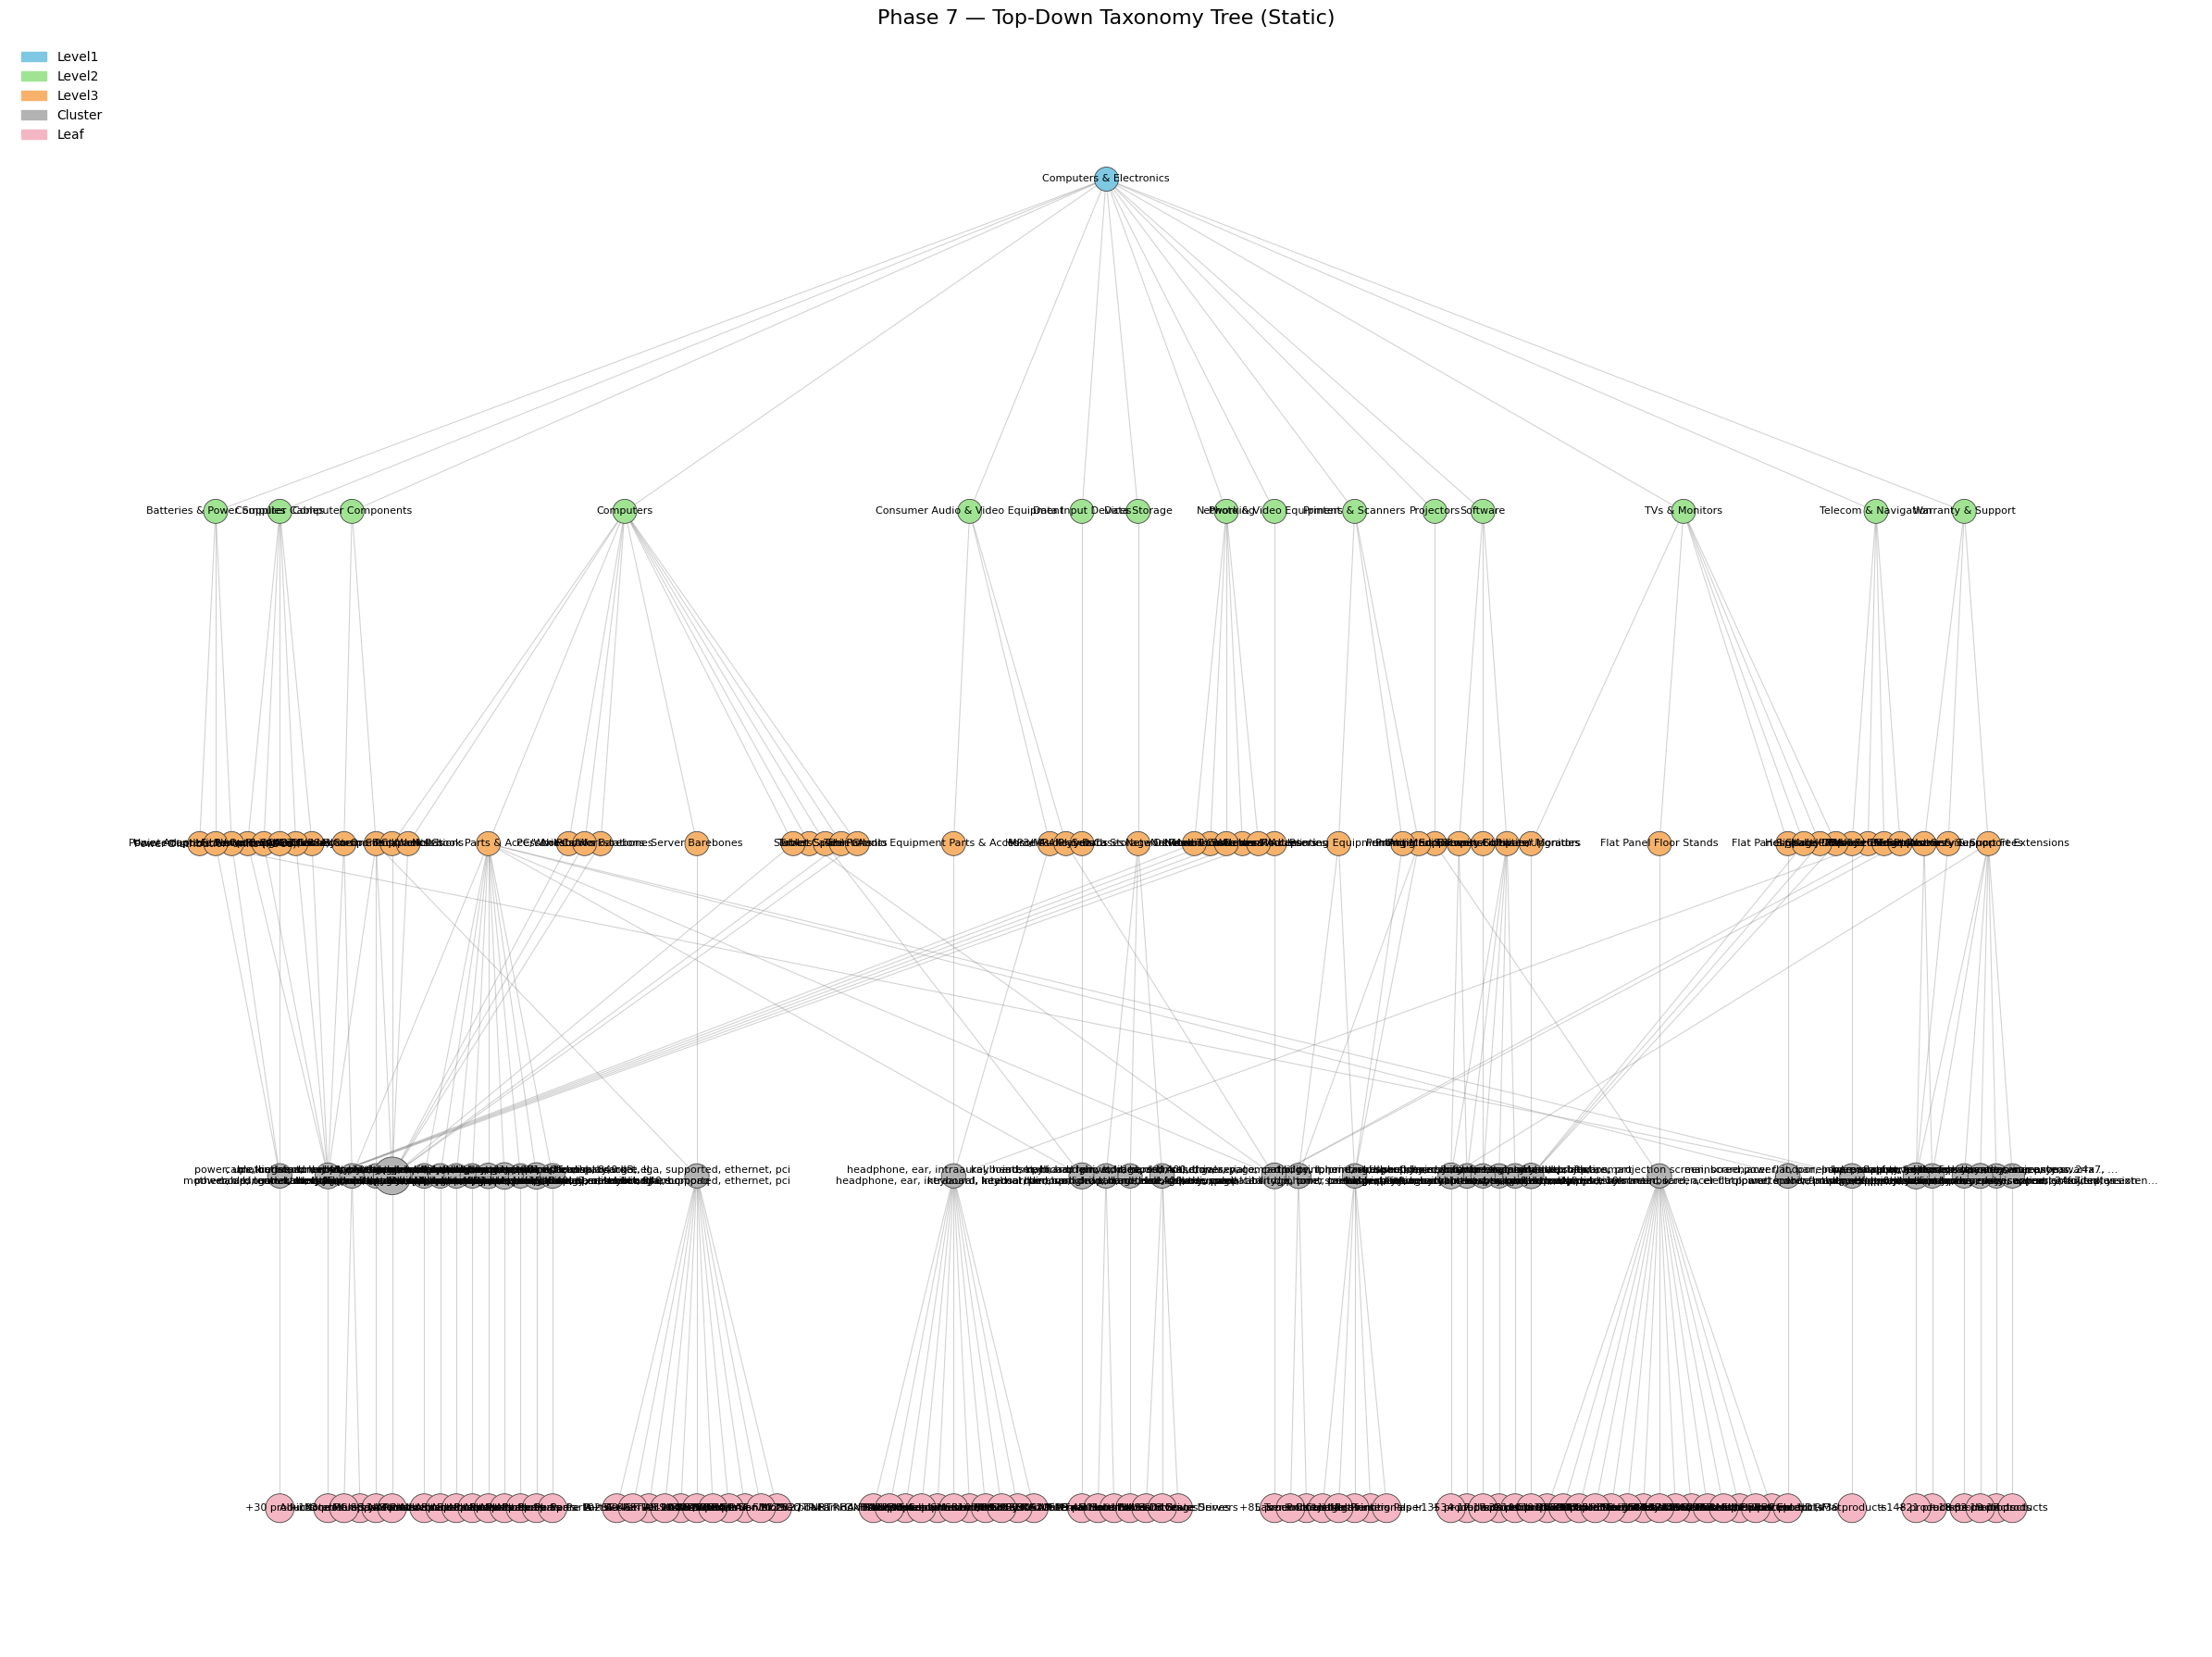

Saved: phase7_tree_static.png
Saved: phase7_tree_static.pdf


In [19]:
# =========================
# Phase 7 (static): Top-Down Taxonomy Tree with Matplotlib
# =========================
# - Loads: phase5_taxonomy_graph.json (from Phase 5)
# - Top-down layered layout (no Graphviz)
# - Colors by node type; cluster size scales node size
# - Optional: add top_terms/keywords under cluster labels
# - Saves PNG/PDF

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from networkx.readwrite import json_graph

# ---------------------------
# Inputs / Toggles
# ---------------------------
GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # from Phase 5
PNG_OUT = "phase7_tree_static.png"
PDF_OUT = "phase7_tree_static.pdf"

FOCUS_L1 = None           # e.g. "Computers & Electronics" or None for all
INCLUDE_LEVEL4 = True     # include product leaves
SHOW_LABELS = True
MAX_LABEL = 40            # truncate main label
SHOW_TERMS = True         # add a 2nd line with terms for cluster nodes
TERMS_SOURCE = "both"     # "top_terms" | "keywords" | "both"
TERMS_K = 5               # how many terms to show
FIGSIZE = (24, 18)        # bigger = more readable
EDGE_ALPHA = 0.35

# ---------------------------
# 1) Load graph
# ---------------------------
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)
print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 2) Optional filtering
# ---------------------------
if FOCUS_L1 is not None:
    roots = [n for n, d in G.nodes(data=True)
             if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if not roots:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found.")
    keep = set([roots[0]])
    keep.update(nx.descendants(G, roots[0]))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

if not INCLUDE_LEVEL4:
    leaves = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(leaves)
    print("Removed Level4 leaves:", len(leaves))

# ---------------------------
# 3) Build a tree-like layout (choose primary parent)
# ---------------------------
level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(n):
    return level_order.get(G.nodes[n].get("type", "cluster"), 4)

# primary parent selection (closest to root)
parents = {n: [] for n in G.nodes()}
for u, v in G.edges():
    parents[v].append(u)
primary_parent = {}
for n in G.nodes():
    ps = parents[n]
    if not ps:
        primary_parent[n] = None
    else:
        ps.sort(key=lambda p: (node_level(p), G.nodes[p].get("label", "")))
        primary_parent[n] = ps[0]

children = defaultdict(list)
for n, p in primary_parent.items():
    if p is not None:
        children[p].append(n)

# roots
roots = [n for n in G.nodes()
         if primary_parent[n] is None and G.nodes[n].get("type") == "level1"]
if not roots:
    roots = [n for n in G.nodes() if primary_parent[n] is None]

# sort children/roots deterministically
for n in children:
    children[n].sort(key=lambda x: G.nodes[x].get("label", ""))
roots.sort(key=lambda x: G.nodes[x].get("label", ""))

# subtree widths so parents can sit centered above children
def subtree_width(n):
    if n not in children or len(children[n]) == 0:
        return 1
    return sum(subtree_width(c) for c in children[n])

xpos, ypos = {}, {}
Y_SPACING = 1.0

def place_subtree(n, x_left):
    w = subtree_width(n)
    x_center = x_left + w / 2.0
    xpos[n] = x_center
    ypos[n] = -node_level(n) * Y_SPACING
    cur = x_left
    for c in children.get(n, []):
        wc = subtree_width(c)
        place_subtree(c, cur)
        cur += wc

# layout each root in sequence with a gap
x_cursor = 0.0
GAP_BETWEEN_ROOTS = 2.0
for r in roots:
    w = subtree_width(r)
    place_subtree(r, x_cursor)
    x_cursor += w + GAP_BETWEEN_ROOTS

# any stragglers (rare)
for n in G.nodes():
    if n not in xpos:
        xpos[n] = x_cursor
        ypos[n] = -node_level(n) * Y_SPACING
        x_cursor += 1.0

pos = {n: (xpos[n], ypos[n]) for n in G.nodes()}

# ---------------------------
# 4) Styling
# ---------------------------
def node_color(d):
    t = d.get("type")
    return {
        "level1": "#7ec8e3",   # sky
        "level2": "#a0e493",   # green
        "level3": "#f6b26b",   # orange
        "cluster": "#b3b3b3",  # gray
        "leaf": "#f4b6c2",     # pink
    }.get(t, "#cccccc")

def node_size(d):
    base = 350
    if d.get("type") == "cluster":
        return max(base, base + 0.4 * d.get("size", 1))  # scale with cluster size
    if d.get("type") == "leaf":
        return 500
    return base

def cluster_label_text(raw):
    # "cid: terms" -> "terms"
    return raw.split(":", 1)[-1].strip() if ":" in (raw or "") else (raw or "")

def trunc(s, n=MAX_LABEL):
    s = s or ""
    return (s[:n-1] + "…") if len(s) > n else s

def second_line_terms(d):
    if not SHOW_TERMS or d.get("type") != "cluster":
        return ""
    top_terms = d.get("top_terms", [])
    keywords = d.get("keywords", [])
    if TERMS_SOURCE == "top_terms":
        bag = top_terms
    elif TERMS_SOURCE == "keywords":
        bag = keywords
    else:  # both
        # preserve order: top_terms first, then keywords
        seen, bag = set(), []
        for t in (top_terms or []) + (keywords or []):
            if t not in seen:
                seen.add(t)
                bag.append(t)
    if not bag:
        return ""
    return "\n" + trunc(", ".join(bag[:TERMS_K]), 60)

# Precompute visuals
sizes = [node_size(d) for _, d in G.nodes(data=True)]
colors = [node_color(d) for _, d in G.nodes(data=True)]
labels = {}
for n, d in G.nodes(data=True):
    raw = d.get("label", "") or str(n)
    main = cluster_label_text(raw) if d.get("type") == "cluster" else raw
    lbl = trunc(main, MAX_LABEL) + second_line_terms(d)
    # skip enormous strings on leaves
    if d.get("type") == "leaf":
        lbl = trunc(main, 30)
    labels[n] = lbl

# ---------------------------
# 5) Draw
# ---------------------------
plt.figure(figsize=FIGSIZE)

# Edges first
nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    alpha=EDGE_ALPHA,
    arrows=False,
    width=0.8
)

# Draw nodes by type (for legend)
type_groups = defaultdict(list)
for n, d in G.nodes(data=True):
    type_groups[d.get("type", "other")].append(n)

for t, nodes in type_groups.items():
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodes,
        node_size=[node_size(G.nodes[n]) for n in nodes],
        node_color=[node_color(G.nodes[n]) for n in nodes],
        linewidths=0.6,
        edgecolors="#444444",
        label=t.title()
    )

# Labels
if SHOW_LABELS:
    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        font_size=8,
        verticalalignment="center",
        horizontalalignment="center"
    )

# Legend
patches = [
    mpatches.Patch(color="#7ec8e3", label="Level1"),
    mpatches.Patch(color="#a0e493", label="Level2"),
    mpatches.Patch(color="#f6b26b", label="Level3"),
    mpatches.Patch(color="#b3b3b3", label="Cluster"),
    mpatches.Patch(color="#f4b6c2", label="Leaf"),
]
plt.legend(handles=patches, loc="upper left", frameon=False)

plt.title("Phase 7 — Top-Down Taxonomy Tree (Static)", fontsize=16, pad=12)
plt.axis("off")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=200)
plt.savefig(PDF_OUT)
plt.show()

print("Saved:", PNG_OUT)
print("Saved:", PDF_OUT)
